# Step 01_02_04 -- Univariate Census & Target Variable EDA: aoestats

**Phase:** 01 -- Data Exploration
**Pipeline Section:** 01_02 -- EDA
**Dataset:** aoestats
**Question:** What are the univariate distributions, NULL rates, and value
profiles for every column in `matches_raw` (18 cols) and `players_raw`
(14 cols)? What is the target variable class balance? What fraction is 1v1?
**Invariants applied:** #3 (temporal -- new_rating leakage note), #6
(reproducibility -- SQL inlined in artifact), #7 (no magic numbers),
#8 (cross-game -- target encoding documented), #9 (step scope: query)
**Step scope:** query
**Type:** Read-only -- no DuckDB writes, no new tables, no schema changes

In [1]:
import json
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import pandas as pd

from rts_predict.common.notebook_utils import get_reports_dir, setup_notebook_logging
from rts_predict.games.aoe2.config import AOESTATS_DB_FILE

logger = setup_notebook_logging()
logger.info("DB_FILE: %s", AOESTATS_DB_FILE)

20:06:22 INFO notebook: DB_FILE: /Users/tomaszpionka/Projects/rts-outcome-prediction/src/rts_predict/games/aoe2/datasets/aoestats/data/db/db.duckdb


In [2]:
con = duckdb.connect(str(AOESTATS_DB_FILE), read_only=True)
print(f"Connected (read-only): {AOESTATS_DB_FILE}")

Connected (read-only): /Users/tomaszpionka/Projects/rts-outcome-prediction/src/rts_predict/games/aoe2/datasets/aoestats/data/db/db.duckdb


In [3]:
artifacts_dir = (
    get_reports_dir("aoe2", "aoestats")
    / "artifacts" / "01_exploration" / "02_eda"
)
artifacts_dir.mkdir(parents=True, exist_ok=True)
plots_dir = artifacts_dir
print(f"Artifacts dir: {artifacts_dir}")

Artifacts dir: /Users/tomaszpionka/Projects/rts-outcome-prediction/src/rts_predict/games/aoe2/datasets/aoestats/reports/artifacts/01_exploration/02_eda


In [4]:
findings: dict = {}
sql_queries: dict = {}

## T07: DuckDB memory footprint

On-disk size of the DuckDB database file (EDA Manual Section 3.2).

In [5]:
import os
db_size_bytes = os.path.getsize(str(AOESTATS_DB_FILE))
print(f"DuckDB file size: {db_size_bytes:,} bytes ({db_size_bytes / 1e9:.2f} GB)")
findings["db_memory_footprint_bytes"] = db_size_bytes

DuckDB file size: 45,386,313,728 bytes (45.39 GB)


## Section A: Full NULL census of matches_raw

All 18 columns -- count and percentage computed in SQL (Invariant #6).

In [6]:
MATCHES_NULL_SQL = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(map) AS map_null,
    ROUND(100.0 * (COUNT(*) - COUNT(map)) / COUNT(*), 2) AS map_null_pct,
    COUNT(*) - COUNT(started_timestamp) AS started_timestamp_null,
    ROUND(100.0 * (COUNT(*) - COUNT(started_timestamp)) / COUNT(*), 2) AS started_timestamp_null_pct,
    COUNT(*) - COUNT(duration) AS duration_null,
    ROUND(100.0 * (COUNT(*) - COUNT(duration)) / COUNT(*), 2) AS duration_null_pct,
    COUNT(*) - COUNT(irl_duration) AS irl_duration_null,
    ROUND(100.0 * (COUNT(*) - COUNT(irl_duration)) / COUNT(*), 2) AS irl_duration_null_pct,
    COUNT(*) - COUNT(game_id) AS game_id_null,
    ROUND(100.0 * (COUNT(*) - COUNT(game_id)) / COUNT(*), 2) AS game_id_null_pct,
    COUNT(*) - COUNT(avg_elo) AS avg_elo_null,
    ROUND(100.0 * (COUNT(*) - COUNT(avg_elo)) / COUNT(*), 2) AS avg_elo_null_pct,
    COUNT(*) - COUNT(num_players) AS num_players_null,
    ROUND(100.0 * (COUNT(*) - COUNT(num_players)) / COUNT(*), 2) AS num_players_null_pct,
    COUNT(*) - COUNT(team_0_elo) AS team_0_elo_null,
    ROUND(100.0 * (COUNT(*) - COUNT(team_0_elo)) / COUNT(*), 2) AS team_0_elo_null_pct,
    COUNT(*) - COUNT(team_1_elo) AS team_1_elo_null,
    ROUND(100.0 * (COUNT(*) - COUNT(team_1_elo)) / COUNT(*), 2) AS team_1_elo_null_pct,
    COUNT(*) - COUNT(replay_enhanced) AS replay_enhanced_null,
    ROUND(100.0 * (COUNT(*) - COUNT(replay_enhanced)) / COUNT(*), 2) AS replay_enhanced_null_pct,
    COUNT(*) - COUNT(leaderboard) AS leaderboard_null,
    ROUND(100.0 * (COUNT(*) - COUNT(leaderboard)) / COUNT(*), 2) AS leaderboard_null_pct,
    COUNT(*) - COUNT(mirror) AS mirror_null,
    ROUND(100.0 * (COUNT(*) - COUNT(mirror)) / COUNT(*), 2) AS mirror_null_pct,
    COUNT(*) - COUNT(patch) AS patch_null,
    ROUND(100.0 * (COUNT(*) - COUNT(patch)) / COUNT(*), 2) AS patch_null_pct,
    COUNT(*) - COUNT(raw_match_type) AS raw_match_type_null,
    ROUND(100.0 * (COUNT(*) - COUNT(raw_match_type)) / COUNT(*), 2) AS raw_match_type_null_pct,
    COUNT(*) - COUNT(game_type) AS game_type_null,
    ROUND(100.0 * (COUNT(*) - COUNT(game_type)) / COUNT(*), 2) AS game_type_null_pct,
    COUNT(*) - COUNT(game_speed) AS game_speed_null,
    ROUND(100.0 * (COUNT(*) - COUNT(game_speed)) / COUNT(*), 2) AS game_speed_null_pct,
    COUNT(*) - COUNT(starting_age) AS starting_age_null,
    ROUND(100.0 * (COUNT(*) - COUNT(starting_age)) / COUNT(*), 2) AS starting_age_null_pct,
    COUNT(*) - COUNT(filename) AS filename_null,
    ROUND(100.0 * (COUNT(*) - COUNT(filename)) / COUNT(*), 2) AS filename_null_pct
FROM matches_raw
"""
sql_queries["matches_null_census"] = MATCHES_NULL_SQL

In [7]:
raw_m = con.execute(MATCHES_NULL_SQL).df()
total_matches = int(raw_m["total_rows"].iloc[0])
print(f"matches_raw total rows: {total_matches:,}")

matches_raw total rows: 30,690,651


In [8]:
MATCHES_COLS = [
    "map", "started_timestamp", "duration", "irl_duration", "game_id",
    "avg_elo", "num_players", "team_0_elo", "team_1_elo",
    "replay_enhanced", "leaderboard", "mirror", "patch",
    "raw_match_type", "game_type", "game_speed", "starting_age",
    "filename",
]

rows = []
for col in MATCHES_COLS:
    null_count = int(raw_m[f"{col}_null"].iloc[0])
    null_pct = float(raw_m[f"{col}_null_pct"].iloc[0])
    rows.append({"column": col, "null_count": null_count, "null_pct": null_pct})

matches_null_df = pd.DataFrame(rows)
print(matches_null_df.to_string(index=False))

           column  null_count  null_pct
              map           0      0.00
started_timestamp           0      0.00
         duration           0      0.00
     irl_duration           0      0.00
          game_id           0      0.00
          avg_elo           0      0.00
      num_players           0      0.00
       team_0_elo           0      0.00
       team_1_elo           0      0.00
  replay_enhanced           0      0.00
      leaderboard           0      0.00
           mirror           0      0.00
            patch           0      0.00
   raw_match_type       12504      0.04
        game_type           0      0.00
       game_speed           0      0.00
     starting_age           0      0.00
         filename           0      0.00


In [9]:
findings["matches_null_census"] = {
    "total_rows": total_matches,
    "columns": rows,
}

## Section B: Full NULL census of players_raw

All 14 columns -- count and percentage computed in SQL (Invariant #6).

In [10]:
PLAYERS_NULL_SQL = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(winner) AS winner_null,
    ROUND(100.0 * (COUNT(*) - COUNT(winner)) / COUNT(*), 2) AS winner_null_pct,
    COUNT(*) - COUNT(game_id) AS game_id_null,
    ROUND(100.0 * (COUNT(*) - COUNT(game_id)) / COUNT(*), 2) AS game_id_null_pct,
    COUNT(*) - COUNT(team) AS team_null,
    ROUND(100.0 * (COUNT(*) - COUNT(team)) / COUNT(*), 2) AS team_null_pct,
    COUNT(*) - COUNT(feudal_age_uptime) AS feudal_age_uptime_null,
    ROUND(100.0 * (COUNT(*) - COUNT(feudal_age_uptime)) / COUNT(*), 2) AS feudal_age_uptime_null_pct,
    COUNT(*) - COUNT(castle_age_uptime) AS castle_age_uptime_null,
    ROUND(100.0 * (COUNT(*) - COUNT(castle_age_uptime)) / COUNT(*), 2) AS castle_age_uptime_null_pct,
    COUNT(*) - COUNT(imperial_age_uptime) AS imperial_age_uptime_null,
    ROUND(100.0 * (COUNT(*) - COUNT(imperial_age_uptime)) / COUNT(*), 2) AS imperial_age_uptime_null_pct,
    COUNT(*) - COUNT(old_rating) AS old_rating_null,
    ROUND(100.0 * (COUNT(*) - COUNT(old_rating)) / COUNT(*), 2) AS old_rating_null_pct,
    COUNT(*) - COUNT(new_rating) AS new_rating_null,
    ROUND(100.0 * (COUNT(*) - COUNT(new_rating)) / COUNT(*), 2) AS new_rating_null_pct,
    COUNT(*) - COUNT(match_rating_diff) AS match_rating_diff_null,
    ROUND(100.0 * (COUNT(*) - COUNT(match_rating_diff)) / COUNT(*), 2) AS match_rating_diff_null_pct,
    COUNT(*) - COUNT(replay_summary_raw) AS replay_summary_raw_null,
    ROUND(100.0 * (COUNT(*) - COUNT(replay_summary_raw)) / COUNT(*), 2) AS replay_summary_raw_null_pct,
    COUNT(*) - COUNT(profile_id) AS profile_id_null,
    ROUND(100.0 * (COUNT(*) - COUNT(profile_id)) / COUNT(*), 2) AS profile_id_null_pct,
    COUNT(*) - COUNT(civ) AS civ_null,
    ROUND(100.0 * (COUNT(*) - COUNT(civ)) / COUNT(*), 2) AS civ_null_pct,
    COUNT(*) - COUNT(opening) AS opening_null,
    ROUND(100.0 * (COUNT(*) - COUNT(opening)) / COUNT(*), 2) AS opening_null_pct,
    COUNT(*) - COUNT(filename) AS filename_null,
    ROUND(100.0 * (COUNT(*) - COUNT(filename)) / COUNT(*), 2) AS filename_null_pct
FROM players_raw
"""
sql_queries["players_null_census"] = PLAYERS_NULL_SQL

In [11]:
raw_p = con.execute(PLAYERS_NULL_SQL).df()
total_players = int(raw_p["total_rows"].iloc[0])
print(f"players_raw total rows: {total_players:,}")

players_raw total rows: 107,627,584


In [12]:
PLAYERS_COLS = [
    "winner", "game_id", "team", "feudal_age_uptime",
    "castle_age_uptime", "imperial_age_uptime", "old_rating",
    "new_rating", "match_rating_diff", "replay_summary_raw",
    "profile_id", "civ", "opening", "filename",
]

rows_p = []
for col in PLAYERS_COLS:
    null_count = int(raw_p[f"{col}_null"].iloc[0])
    null_pct = float(raw_p[f"{col}_null_pct"].iloc[0])
    rows_p.append({"column": col, "null_count": null_count, "null_pct": null_pct})

players_null_df = pd.DataFrame(rows_p)
print(players_null_df.to_string(index=False))

             column  null_count  null_pct
             winner           0      0.00
            game_id           0      0.00
               team           0      0.00
  feudal_age_uptime    93726448     87.08
  castle_age_uptime    94641831     87.93
imperial_age_uptime    98468904     91.49
         old_rating           0      0.00
         new_rating           0      0.00
  match_rating_diff          39      0.00
 replay_summary_raw           0      0.00
         profile_id        1185      0.00
                civ           0      0.00
            opening    92616290     86.05
           filename           0      0.00


In [13]:
findings["players_null_census"] = {
    "total_rows": total_players,
    "columns": rows_p,
}

## Section B.2: NULL Co-occurrence Analysis

Test whether the four high-NULL columns co-occur in their NULL/non-NULL patterns.
Hypothesis: they co-occur with replay_enhanced=FALSE.

In [14]:
NULL_COOCCURRENCE_SQL = """
SELECT
    COUNT(*) FILTER (WHERE feudal_age_uptime IS NULL
        AND castle_age_uptime IS NULL
        AND imperial_age_uptime IS NULL
        AND opening IS NULL) AS all_four_null,
    COUNT(*) FILTER (WHERE feudal_age_uptime IS NOT NULL
        OR castle_age_uptime IS NOT NULL
        OR imperial_age_uptime IS NOT NULL
        OR opening IS NOT NULL) AS at_least_one_not_null,
    COUNT(*) AS total_rows
FROM players_raw
"""
sql_queries["players_raw_null_cooccurrence"] = NULL_COOCCURRENCE_SQL
cooccur_df = con.execute(NULL_COOCCURRENCE_SQL).df()
print("players_raw NULL co-occurrence:")
print(cooccur_df.to_string(index=False))
findings["players_raw_null_cooccurrence"] = {
    k: int(v) for k, v in cooccur_df.iloc[0].to_dict().items()
}

players_raw NULL co-occurrence:
 all_four_null  at_least_one_not_null  total_rows
      92616290               15011294   107627584


## Section C: Target variable (winner) distribution

The prediction target is `winner` (BOOLEAN: TRUE/FALSE/NULL).
Unlike sc2egset's `result` (VARCHAR), this is a three-state column.

**Note:** 1v1-restricted winner distribution is deferred pending
`num_players` semantics analysis (Section D).

In [15]:
WINNER_SQL = """
SELECT
    winner,
    COUNT(*) AS cnt,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
FROM players_raw
GROUP BY winner
ORDER BY cnt DESC
"""
sql_queries["winner_distribution"] = WINNER_SQL

In [16]:
winner_df = con.execute(WINNER_SQL).df()
print(winner_df.to_string(index=False))

 winner      cnt  pct
  False 53816397 50.0
   True 53811187 50.0


In [17]:
findings["winner_distribution"] = winner_df.to_dict(orient="records")

In [18]:
print("Data feeding winner bar chart:")
print(winner_df.to_string(index=False))

Data feeding winner bar chart:
 winner      cnt  pct
  False 53816397 50.0
   True 53811187 50.0


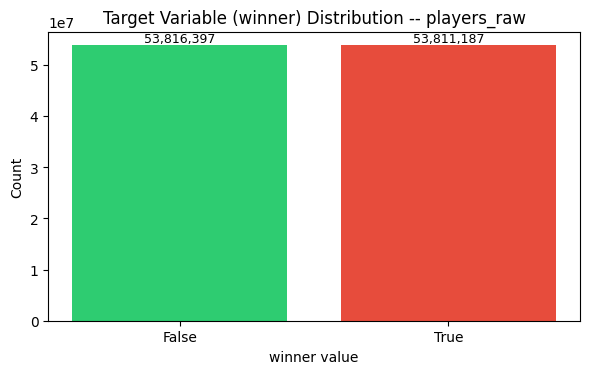

In [19]:
labels = winner_df["winner"].astype(str).tolist()
counts = winner_df["cnt"].tolist()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts, color=["#2ecc71", "#e74c3c", "#95a5a6"])
ax.set_xlabel("winner value")
ax.set_ylabel("Count")
ax.set_title("Target Variable (winner) Distribution -- players_raw")
for bar, c in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height(),
        f"{c:,.0f}", ha="center", va="bottom", fontsize=9,
    )
plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_winner_distribution.png", dpi=150)
plt.show()
plt.close()

## Section D: Player-count distribution (thesis scope gate)

The thesis focuses on 1v1 prediction. `num_players` determines scope.

In [20]:
NUM_PLAYERS_SQL = """
SELECT
    num_players,
    COUNT(*) AS row_count,
    COUNT(DISTINCT game_id) AS distinct_match_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct,
    ROUND(
        100.0 * COUNT(DISTINCT game_id)
        / SUM(COUNT(DISTINCT game_id)) OVER(), 2
    ) AS distinct_match_pct
FROM matches_raw
GROUP BY num_players
ORDER BY num_players
"""
sql_queries["num_players_distribution"] = NUM_PLAYERS_SQL

In [21]:
num_players_df = con.execute(NUM_PLAYERS_SQL).df()
print(num_players_df.to_string(index=False))

 num_players  row_count  distinct_match_count   pct  distinct_match_pct
           1         39                    39  0.00                0.00
           2   18586063              18586063 60.56               60.56
           3        350                   350  0.00                0.00
           4    5057269               5057269 16.48               16.48
           5        327                   327  0.00                0.00
           6    2736203               2736203  8.92                8.92
           7        651                   651  0.00                0.00
           8    4309749               4309749 14.04               14.04


In [22]:
findings["num_players_distribution"] = num_players_df.to_dict(orient="records")

## Section E: Categorical field profiles

Loop-based cells for all categoricals listed in the plan.
Bar charts for top-k value frequencies.

### E.1 matches_raw categoricals

In [23]:
MATCHES_CATEGORICALS = [
    ("matches_raw", "map", 20),
    ("matches_raw", "leaderboard", 50),
    ("matches_raw", "game_type", 50),
    ("matches_raw", "game_speed", 50),
    ("matches_raw", "starting_age", 50),
    ("matches_raw", "replay_enhanced", 10),
    ("matches_raw", "mirror", 10),
    ("matches_raw", "patch", 50),
    ("matches_raw", "raw_match_type", 50),
]

cat_profiles_matches: dict = {}

In [24]:
for table, col, topk in MATCHES_CATEGORICALS:
    sql = f"""
SELECT {col}, COUNT(*) AS cnt,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
FROM {table}
GROUP BY {col}
ORDER BY cnt DESC
LIMIT {topk}
"""
    df = con.execute(sql).df()
    cardinality_sql = f"SELECT COUNT(DISTINCT {col}) AS card FROM {table}"
    card = int(con.execute(cardinality_sql).df()["card"].iloc[0])
    cat_profiles_matches[col] = {
        "cardinality": card,
        "top_values": df.to_dict(orient="records"),
    }
    sql_queries[f"cat_{table}_{col}"] = sql.strip()
    print(f"\n=== {table}.{col} (cardinality={card}) ===")
    print(df.to_string(index=False))


=== matches_raw.map (cardinality=93) ===
             map      cnt   pct
          arabia 10722310 34.94
           arena  5838677 19.02
           nomad  2130289  6.94
    black_forest  1969451  6.42
      megarandom  1894927  6.17
african_clearing   741916  2.42
         hideout   503675  1.64
      land_nomad   348773  1.14
        enclosed   343501  1.12
        fortress   325002  1.06
      four_lakes   308723  1.01
           oasis   278105  0.91
       gold_rush   277101  0.90
         yucatan   266651  0.87
       lombardia   233656  0.76
         lowland   233439  0.76
          haboob   225084  0.73
          steppe   218429  0.71
         socotra   195849  0.64
   amazon_tunnel   184058  0.60

=== matches_raw.leaderboard (cardinality=4) ===
       leaderboard      cnt   pct
        random_map 17959543 58.52
   team_random_map 11518477 37.53
     co_random_map   626542  2.04
co_team_random_map   586089  1.91

=== matches_raw.game_type (cardinality=1) ===
 game_type      cnt 


=== matches_raw.raw_match_type (cardinality=8) ===
 raw_match_type      cnt   pct
            6.0 17952488 58.49
            7.0  4667830 15.21
            9.0  4258413 13.88
            8.0  2587688  8.43
           66.0   626112  2.04
           67.0   387358  1.26
           68.0   147570  0.48
           69.0    50688  0.17
            NaN    12504  0.04


In [25]:
findings["categorical_matches"] = cat_profiles_matches

### E.2 players_raw categoricals

In [26]:
PLAYERS_CATEGORICALS = [
    ("players_raw", "civ", 50),
    ("players_raw", "opening", 30),
    ("players_raw", "team", 20),
    ("players_raw", "replay_summary_raw", 20),
]

cat_profiles_players: dict = {}

In [27]:
for table, col, topk in PLAYERS_CATEGORICALS:
    sql = f"""
SELECT {col}, COUNT(*) AS cnt,
       ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
FROM {table}
GROUP BY {col}
ORDER BY cnt DESC
LIMIT {topk}
"""
    df = con.execute(sql).df()
    cardinality_sql = f"SELECT COUNT(DISTINCT {col}) AS card FROM {table}"
    card = int(con.execute(cardinality_sql).df()["card"].iloc[0])
    cat_profiles_players[col] = {
        "cardinality": card,
        "top_values": df.to_dict(orient="records"),
    }
    sql_queries[f"cat_{table}_{col}"] = sql.strip()
    print(f"\n=== {table}.{col} (cardinality={card}) ===")
    print(df.to_string(index=False))


=== players_raw.civ (cardinality=50) ===
        civ     cnt  pct
     franks 6018585 5.59
    mongols 5638014 5.24
   persians 4619647 4.29
    britons 4341837 4.03
    spanish 4177105 3.88
      khmer 4085981 3.80
    teutons 3200380 2.97
 ethiopians 3167924 2.94
       huns 3110832 2.89
      goths 3002766 2.79
      turks 2993590 2.78
    magyars 2936741 2.73
lithuanians 2711792 2.52
 byzantines 2542380 2.36
 portuguese 2537718 2.36
     cumans 2520564 2.34
 vietnamese 2482093 2.31
  bohemians 2397273 2.23
hindustanis 2377856 2.21
     mayans 2324086 2.16
   italians 2320636 2.16
      celts 2178093 2.02
   japanese 2121211 1.97
      poles 2021303 1.88
   saracens 2018581 1.88
burgundians 1977224 1.84
    vikings 1795192 1.67
    chinese 1753341 1.63
     romans 1706541 1.59
    koreans 1695859 1.58
 bulgarians 1678614 1.56
      slavs 1665251 1.55
    malians 1626659 1.51
    berbers 1608809 1.49
      incas 1561464 1.45
      malay 1544367 1.43
     aztecs 1463219 1.36
  sicili


=== players_raw.opening (cardinality=10) ===
    opening      cnt   pct
        NaN 92616290 86.05
fast_castle  4200028  3.90
    unknown  3589615  3.34
     scouts  2117251  1.97
    archers  1974622  1.83
      trash  1099518  1.02
man_at_arms  1092885  1.02
      fires   360897  0.34
      drush   238173  0.22
    galleys   179940  0.17
     towers   158365  0.15



=== players_raw.team (cardinality=2) ===
 team      cnt  pct
    0 53814014 50.0
    1 53813570 50.0



=== players_raw.replay_summary_raw (cardinality=13983149) ===
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    replay_summary_raw      cnt   pct
                                                                                                                                                                                                                                                                                                                                                                                                                   

In [28]:
findings["categorical_players"] = cat_profiles_players

### E.3 opening non-NULL distribution

The opening column is 86% NULL. Profile only the non-NULL subset.

In [29]:
OPENING_NONNULL_SQL = """
SELECT
    opening,
    COUNT(*) AS cnt,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct_of_nonnull
FROM players_raw
WHERE opening IS NOT NULL
GROUP BY opening
ORDER BY cnt DESC
"""
sql_queries["opening_nonnull_distribution"] = OPENING_NONNULL_SQL
opening_nn_df = con.execute(OPENING_NONNULL_SQL).df()
print(f"opening non-NULL rows: {opening_nn_df['cnt'].sum():,}")
print(opening_nn_df.to_string(index=False))
findings["opening_nonnull_distribution"] = {
    "total_nonnull": int(opening_nn_df["cnt"].sum()),
    "values": opening_nn_df.to_dict(orient="records"),
}

opening non-NULL rows: 15,011,294
    opening     cnt  pct_of_nonnull
fast_castle 4200028           27.98
    unknown 3589615           23.91
     scouts 2117251           14.10
    archers 1974622           13.15
      trash 1099518            7.32
man_at_arms 1092885            7.28
      fires  360897            2.40
      drush  238173            1.59
    galleys  179940            1.20
     towers  158365            1.05


### E.5 Categorical bar charts

Multi-panel bar charts for the most informative categoricals.

In [30]:
cat_plot_cols_m = [
    ("matches_raw", "map", 15),
    ("matches_raw", "leaderboard", 20),
    ("matches_raw", "game_type", 20),
    ("matches_raw", "game_speed", 10),
    ("matches_raw", "starting_age", 10),
]

Data feeding matches_raw categorical bar charts:

  matches_raw.map (top 15 of 20):
               map      cnt   pct
          arabia 10722310 34.94
           arena  5838677 19.02
           nomad  2130289  6.94
    black_forest  1969451  6.42
      megarandom  1894927  6.17
african_clearing   741916  2.42
         hideout   503675  1.64
      land_nomad   348773  1.14
        enclosed   343501  1.12
        fortress   325002  1.06
      four_lakes   308723  1.01
           oasis   278105  0.91
       gold_rush   277101  0.90
         yucatan   266651  0.87
       lombardia   233656  0.76

  matches_raw.leaderboard (top 20 of 4):
         leaderboard      cnt   pct
        random_map 17959543 58.52
   team_random_map 11518477 37.53
     co_random_map   626542  2.04
co_team_random_map   586089  1.91

  matches_raw.game_type (top 20 of 1):
   game_type      cnt   pct
random_map 30690651 100.0

  matches_raw.game_speed (top 10 of 1):
  game_speed      cnt   pct
    normal 30690651 100.0

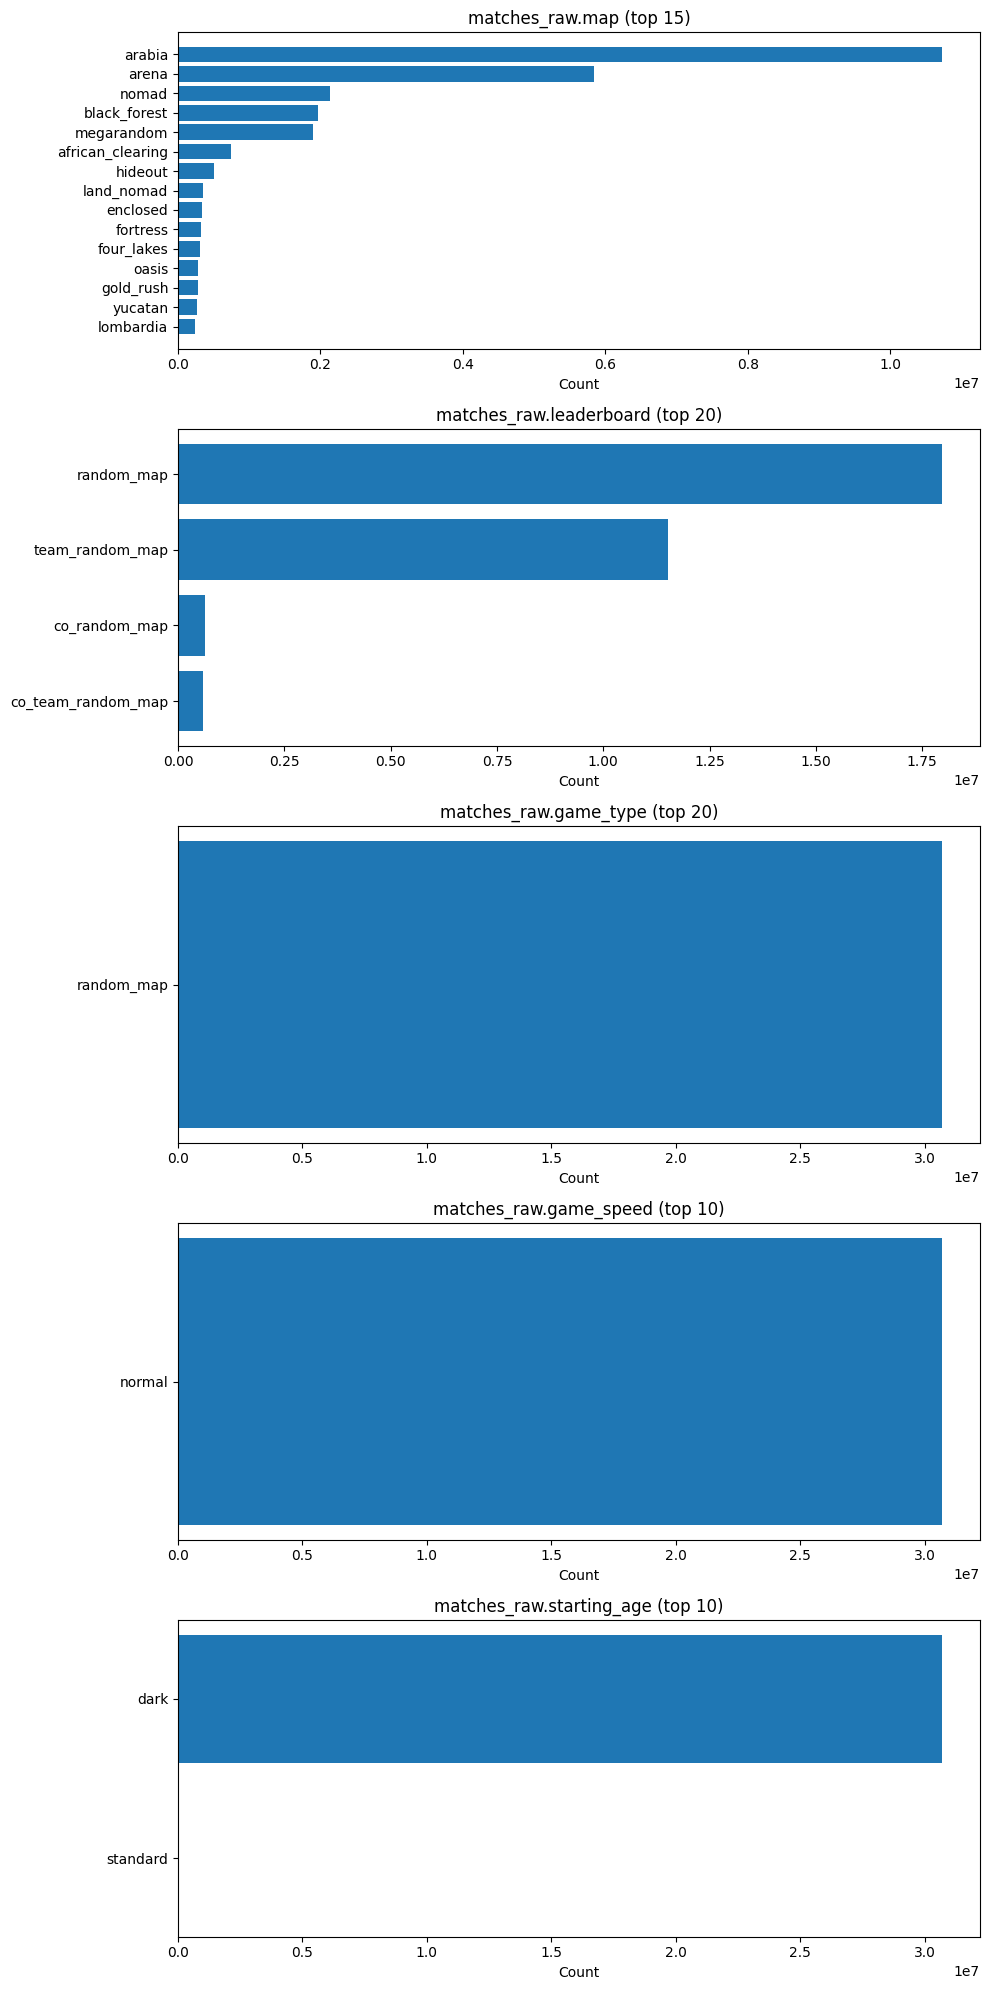

In [31]:
print("Data feeding matches_raw categorical bar charts:")
for table, col, topk in cat_plot_cols_m:
    vals = cat_profiles_matches[col]["top_values"][:topk]
    print(f"\n  {table}.{col} (top {topk} of {len(cat_profiles_matches[col]['top_values'])}):")
    print(f"  {pd.DataFrame(vals).to_string(index=False)}")

fig, axes = plt.subplots(len(cat_plot_cols_m), 1, figsize=(10, 4 * len(cat_plot_cols_m)))
for ax, (table, col, topk) in zip(axes, cat_plot_cols_m):
    vals = cat_profiles_matches[col]["top_values"][:topk]
    labels_c = [str(v[col]) for v in vals]
    counts_c = [v["cnt"] for v in vals]
    ax.barh(labels_c[::-1], counts_c[::-1])
    ax.set_title(f"{table}.{col} (top {topk})")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_categorical_bars_matches.png", dpi=150)
plt.show()
plt.close()

In [32]:
cat_plot_cols_p = [
    ("players_raw", "civ", 20),
    ("players_raw", "opening", 15),
    ("players_raw", "team", 10),
]

20:06:58 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


20:06:58 INFO matplotlib.category: Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Data feeding players_raw categorical bar charts:

  players_raw.civ (top 20 of 50):
          civ     cnt  pct
     franks 6018585 5.59
    mongols 5638014 5.24
   persians 4619647 4.29
    britons 4341837 4.03
    spanish 4177105 3.88
      khmer 4085981 3.80
    teutons 3200380 2.97
 ethiopians 3167924 2.94
       huns 3110832 2.89
      goths 3002766 2.79
      turks 2993590 2.78
    magyars 2936741 2.73
lithuanians 2711792 2.52
 byzantines 2542380 2.36
 portuguese 2537718 2.36
     cumans 2520564 2.34
 vietnamese 2482093 2.31
  bohemians 2397273 2.23
hindustanis 2377856 2.21
     mayans 2324086 2.16

  players_raw.opening (top 15 of 11):
      opening      cnt   pct
        NaN 92616290 86.05
fast_castle  4200028  3.90
    unknown  3589615  3.34
     scouts  2117251  1.97
    archers  1974622  1.83
      trash  1099518  1.02
man_at_arms  1092885  1.02
      fires   360897  0.34
      drush   238173  0.22
    galleys   179940  0.17
     towers   158365  0.15

  players_raw.team (top

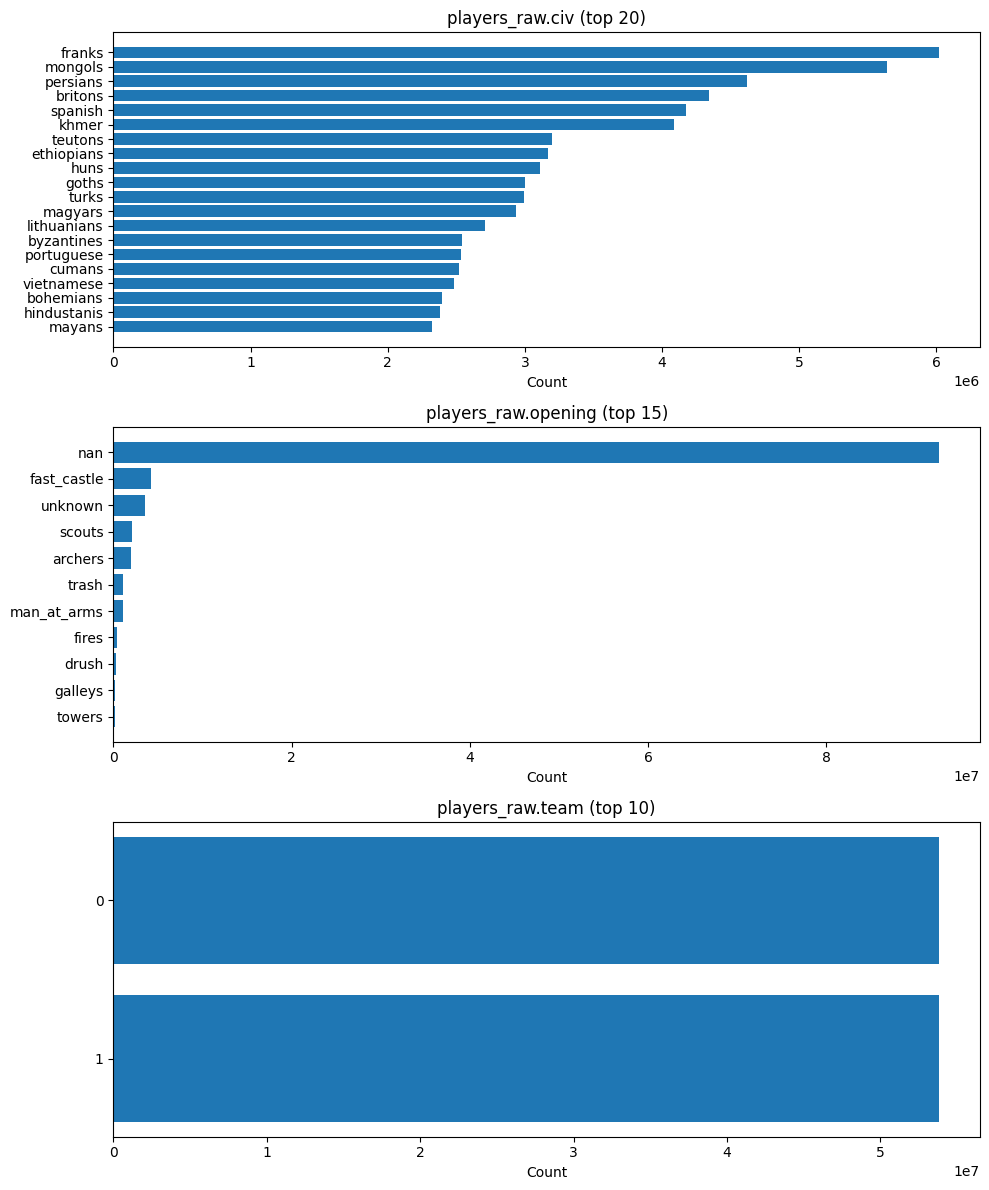

In [33]:
print("Data feeding players_raw categorical bar charts:")
for table, col, topk in cat_plot_cols_p:
    vals = cat_profiles_players[col]["top_values"][:topk]
    print(f"\n  {table}.{col} (top {topk} of {len(cat_profiles_players[col]['top_values'])}):")
    print(f"  {pd.DataFrame(vals).to_string(index=False)}")

fig, axes = plt.subplots(len(cat_plot_cols_p), 1, figsize=(10, 4 * len(cat_plot_cols_p)))
for ax, (table, col, topk) in zip(axes, cat_plot_cols_p):
    vals = cat_profiles_players[col]["top_values"][:topk]
    labels_c = [str(v[col]) for v in vals]
    counts_c = [v["cnt"] for v in vals]
    ax.barh(labels_c[::-1], counts_c[::-1])
    ax.set_title(f"{table}.{col} (top {topk})")
    ax.set_xlabel("Count")

plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_categorical_bars_players.png", dpi=150)
plt.show()
plt.close()

## Section F: Numeric descriptive statistics

DuckDB-side aggregation for all numeric columns.
Duration columns divided by 1e9 for seconds.
For high-NULL columns (age uptimes), note limited non-NULL sample.

### F.1 matches_raw numerics

In [34]:
MATCHES_NUMERIC_DEFS = [
    ("matches_raw", "duration / 1e9", "duration_sec"),
    ("matches_raw", "irl_duration / 1e9", "irl_duration_sec"),
    ("matches_raw", "avg_elo", "avg_elo"),
    ("matches_raw", "team_0_elo", "team_0_elo"),
    ("matches_raw", "team_1_elo", "team_1_elo"),
    ("matches_raw", "raw_match_type", "raw_match_type"),
    ("matches_raw", "patch", "patch"),
]

numeric_stats_matches: list = []

In [35]:
for table, expr, label in MATCHES_NUMERIC_DEFS:
    sql = f"""
SELECT
    COUNT({expr}) AS n_nonnull,
    COUNT(*) - COUNT({expr}) AS n_null,
    SUM(CASE WHEN {expr} = 0 THEN 1 ELSE 0 END) AS n_zero,
    MIN({expr}) AS min_val,
    MAX({expr}) AS max_val,
    ROUND(AVG({expr}), 2) AS mean_val,
    ROUND(MEDIAN({expr}), 2) AS median_val,
    ROUND(STDDEV({expr}), 2) AS stddev_val,
    ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY {expr}), 2) AS p05,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {expr}), 2) AS p25,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY {expr}), 2) AS p50,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {expr}), 2) AS p75,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY {expr}), 2) AS p95
FROM {table}
"""
    df = con.execute(sql).df()
    rec = df.iloc[0].to_dict()
    rec = {k: float(v) if pd.notna(v) else None for k, v in rec.items()}
    rec["label"] = label
    numeric_stats_matches.append(rec)
    sql_queries[f"numeric_{table}_{label}"] = sql.strip()
    print(f"\n=== {label} ({table}) ===")
    print(df.to_string(index=False))


=== duration_sec (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val   max_val  mean_val  median_val  stddev_val   p05    p25    p50    p75    p95
  30690651       0     0.0      3.4 5574815.1   2613.68      2619.7     1857.49 285.6 1824.1 2619.7 3292.9 4714.1



=== irl_duration_sec (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val   max_val  mean_val  median_val  stddev_val   p05    p25    p50    p75    p95
  30690651       0     0.0      2.0 3279303.0   1537.46      1541.0     1092.64 168.0 1073.0 1541.0 1937.0 2773.0



=== avg_elo (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
  30690651       0   121.0      0.0   2976.5    1087.6      1055.0      309.54 637.0 886.5 1055.0 1260.5 1630.0



=== team_0_elo (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
  30690651       0  4824.0     -1.0   3038.0   1082.67      1051.5      312.31 625.5 881.5 1051.5 1258.0 1629.0



=== team_1_elo (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
  30690651       0   192.0     -1.0   3045.0   1092.53      1058.0      309.32 646.0 890.5 1058.0 1264.0 1636.0



=== raw_match_type (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val  p05  p25  p50  p75  p95
  30678147   12504     0.0      6.0     69.0      9.13         6.0       11.72  6.0  6.0  6.0  8.0  9.0



=== patch (matches_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val     p05     p25      p50      p75      p95
  30690651       0     0.0    66692   162286 115148.33    111772.0    25595.92 78174.0 93001.0 111772.0 141935.0 162286.0


In [36]:
findings["numeric_stats_matches"] = numeric_stats_matches

### F.2 players_raw numerics

In [37]:
PLAYERS_NUMERIC_DEFS = [
    ("players_raw", "old_rating", "old_rating"),
    ("players_raw", "new_rating", "new_rating"),
    ("players_raw", "match_rating_diff", "match_rating_diff"),
    ("players_raw", "feudal_age_uptime", "feudal_age_uptime"),
    ("players_raw", "castle_age_uptime", "castle_age_uptime"),
    ("players_raw", "imperial_age_uptime", "imperial_age_uptime"),
]

numeric_stats_players: list = []

In [38]:
for table, expr, label in PLAYERS_NUMERIC_DEFS:
    sql = f"""
SELECT
    COUNT({expr}) AS n_nonnull,
    COUNT(*) - COUNT({expr}) AS n_null,
    SUM(CASE WHEN {expr} = 0 THEN 1 ELSE 0 END) AS n_zero,
    MIN({expr}) AS min_val,
    MAX({expr}) AS max_val,
    ROUND(AVG({expr}), 2) AS mean_val,
    ROUND(MEDIAN({expr}), 2) AS median_val,
    ROUND(STDDEV({expr}), 2) AS stddev_val,
    ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY {expr}), 2) AS p05,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {expr}), 2) AS p25,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY {expr}), 2) AS p50,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {expr}), 2) AS p75,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY {expr}), 2) AS p95
FROM {table}
"""
    df = con.execute(sql).df()
    rec = df.iloc[0].to_dict()
    rec = {k: float(v) if pd.notna(v) else None for k, v in rec.items()}
    rec["label"] = label
    numeric_stats_players.append(rec)
    sql_queries[f"numeric_{table}_{label}"] = sql.strip()
    print(f"\n=== {label} ({table}) ===")
    print(df.to_string(index=False))


=== old_rating (players_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
 107627584       0  5937.0        0     3045    1091.1      1066.0      286.86 665.0 900.0 1066.0 1263.0 1580.0



=== new_rating (players_raw) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
 107627584       0  5187.0       -5     3045   1090.81      1067.0      287.48 663.0 899.0 1067.0 1263.0 1581.0



=== match_rating_diff (players_raw) ===
 n_nonnull  n_null    n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25  p50  p75  p95
 107627545      39 1117846.0  -2185.0   2185.0       0.0         0.0       55.23 -59.0 -17.0  0.0 17.0 59.0



=== feudal_age_uptime (players_raw) ===
 n_nonnull   n_null  n_zero    min_val   max_val  mean_val  median_val  stddev_val    p05    p25    p50    p75    p95
  13901136 93726448     0.0 104.318329 12551.634    706.82      680.22      143.07 535.11 611.52 680.22 774.38 962.59



=== castle_age_uptime (players_raw) ===
 n_nonnull   n_null  n_zero    min_val   max_val  mean_val  median_val  stddev_val    p05     p25     p50     p75     p95
  12985753 94641831     0.0 301.254328 15545.251    1275.4     1262.91       282.6 889.07 1069.66 1262.91 1427.34 1752.13



=== imperial_age_uptime (players_raw) ===
 n_nonnull   n_null  n_zero    min_val   max_val  mean_val  median_val  stddev_val     p05     p25     p50     p75     p95
   9158680 98468904     0.0 769.397327 24264.405   2240.87     2208.64      404.97 1681.08 1966.16 2208.64 2462.87 2932.96


In [39]:
findings["numeric_stats_players"] = numeric_stats_players

### F.8 Skewness and Kurtosis

EDA Manual Section 3.1 requires distribution shape (skewness, kurtosis) for
all numeric columns. For high-NULL columns, stats are computed on non-NULL subset only.

In [40]:
skew_kurt_matches = []
for table, expr, label in MATCHES_NUMERIC_DEFS:
    sql = f"""
SELECT
    ROUND(SKEWNESS({expr}), 4) AS skewness,
    ROUND(KURTOSIS({expr}), 4) AS kurtosis,
    COUNT({expr}) AS n_nonnull
FROM {table}
"""
    df = con.execute(sql).df()
    rec = df.iloc[0].to_dict()
    rec = {k: float(v) if pd.notna(v) else None for k, v in rec.items()}
    rec["label"] = label
    n_null_for_label = next(
        s for s in numeric_stats_matches if s["label"] == label
    )["n_null"]
    if n_null_for_label and n_null_for_label > 0:
        rec["note"] = (
            f"Computed on {int(rec['n_nonnull']):,} non-NULL values only; "
            f"{int(n_null_for_label):,} NULLs excluded"
        )
    skew_kurt_matches.append(rec)
    sql_queries[f"skew_kurt_matches_{label}"] = sql.strip()
    print(f"{label}: skewness={rec['skewness']}, kurtosis={rec['kurtosis']}")

duration_sec: skewness=1032.6426, kurtosis=2808033.6539
irl_duration_sec: skewness=1032.6426, kurtosis=2808033.6539
avg_elo: skewness=0.6648, kurtosis=1.5165


team_0_elo: skewness=0.6103, kurtosis=1.4823


team_1_elo: skewness=0.7295, kurtosis=1.6468
raw_match_type: skewness=4.6654, kurtosis=19.9837


patch: skewness=0.1964, kurtosis=-1.1006


In [41]:
skew_kurt_players = []
for table, expr, label in PLAYERS_NUMERIC_DEFS:
    sql = f"""
SELECT
    ROUND(SKEWNESS({expr}), 4) AS skewness,
    ROUND(KURTOSIS({expr}), 4) AS kurtosis,
    COUNT({expr}) AS n_nonnull
FROM {table}
"""
    df = con.execute(sql).df()
    rec = df.iloc[0].to_dict()
    rec = {k: float(v) if pd.notna(v) else None for k, v in rec.items()}
    rec["label"] = label
    n_null_for_label = next(
        s for s in numeric_stats_players if s["label"] == label
    )["n_null"]
    if n_null_for_label and n_null_for_label > 0:
        rec["note"] = (
            f"Computed on {int(rec['n_nonnull']):,} non-NULL values only; "
            f"{int(n_null_for_label):,} NULLs excluded"
        )
    skew_kurt_players.append(rec)
    sql_queries[f"skew_kurt_players_{label}"] = sql.strip()
    print(f"{label}: skewness={rec['skewness']}, kurtosis={rec['kurtosis']}")

old_rating: skewness=0.5419, kurtosis=1.3
new_rating: skewness=0.5371, kurtosis=1.2841


match_rating_diff: skewness=0.0, kurtosis=65.6753
feudal_age_uptime: skewness=2.0437, kurtosis=18.3849
castle_age_uptime: skewness=1.1732, kurtosis=5.2887
imperial_age_uptime: skewness=0.9882, kurtosis=4.802


In [42]:
findings["skew_kurtosis_matches"] = skew_kurt_matches
findings["skew_kurtosis_players"] = skew_kurt_players

### F.3 profile_id min/max (ID safety gate)

profile_id is DOUBLE -- confirm max < 2^53 to avoid precision loss.

In [43]:
PROFILE_ID_SQL = """
SELECT
    COUNT(profile_id) AS n_nonnull,
    COUNT(*) - COUNT(profile_id) AS n_null,
    MIN(profile_id) AS min_val,
    MAX(profile_id) AS max_val
FROM players_raw
"""
sql_queries["profile_id_range"] = PROFILE_ID_SQL

In [44]:
pid_df = con.execute(PROFILE_ID_SQL).df()
print(pid_df.to_string(index=False))
max_pid = float(pid_df["max_val"].iloc[0])
print(f"Max profile_id: {max_pid:,.0f}  |  2^53 = {2**53:,}")
print(f"Below 2^53 safety threshold: {max_pid < 2**53}")

 n_nonnull  n_null  min_val    max_val
 107626399    1185     18.0 24853897.0
Max profile_id: 24,853,897  |  2^53 = 9,007,199,254,740,992
Below 2^53 safety threshold: True


In [45]:
findings["profile_id_range"] = {
    "n_nonnull": int(pid_df["n_nonnull"].iloc[0]),
    "n_null": int(pid_df["n_null"].iloc[0]),
    "min_val": float(pid_df["min_val"].iloc[0]),
    "max_val": max_pid,
    "below_2_53": max_pid < 2**53,
}

### F.4 Numeric histograms (DuckDB-side binning)

For 107.6M-row tables: bin in SQL, plot in matplotlib.

In [46]:
HIST_DEFS_MATCHES = [
    ("matches_raw", "duration / 1e9", "duration_sec", 60),
    ("matches_raw", "irl_duration / 1e9", "irl_duration_sec", 60),
    ("matches_raw", "avg_elo", "avg_elo", 50),
]

hist_data: dict = {}

for table, expr, label, bin_width in HIST_DEFS_MATCHES:
    sql = f"""
SELECT
    FLOOR({expr} / {bin_width}) * {bin_width} AS bin,
    COUNT(*) AS cnt
FROM {table}
WHERE {expr} IS NOT NULL
GROUP BY bin
ORDER BY bin
"""
    df = con.execute(sql).df()
    hist_data[label] = df
    sql_queries[f"hist_{label}"] = sql.strip()

In [47]:
print("Data feeding matches numeric histograms:")
for table, expr, label, _ in HIST_DEFS_MATCHES:
    df = hist_data[label]
    print(f"\n  {label}: {len(df)} bins, first 5:")
    print(f"  {df.head(5).to_string(index=False)}")
    print(f"  ...last 5:")
    print(f"  {df.tail(5).to_string(index=False)}")

Data feeding matches numeric histograms:

  duration_sec: 1052 bins, first 5:
    bin    cnt
  0.0 675533
 60.0 304616
120.0 231213
180.0 187755
240.0 175056
  ...last 5:
        bin  cnt
1020360.0    1
1625700.0    1
1745760.0    1
2568180.0    1
5574780.0    1

  irl_duration_sec: 739 bins, first 5:
    bin    cnt
  0.0 892052
 60.0 395953
120.0 300166
180.0 324760
240.0 217610
  ...last 5:
        bin  cnt
 600180.0    1
 956280.0    1
1026900.0    1
1510680.0    1
3279300.0    1

  avg_elo: 60 bins, first 5:
    bin   cnt
  0.0  3161
 50.0  7261
100.0 11991
150.0 18340
200.0 27057
  ...last 5:
     bin  cnt
2750.0 1272
2800.0  664
2850.0  235
2900.0   43
2950.0    7


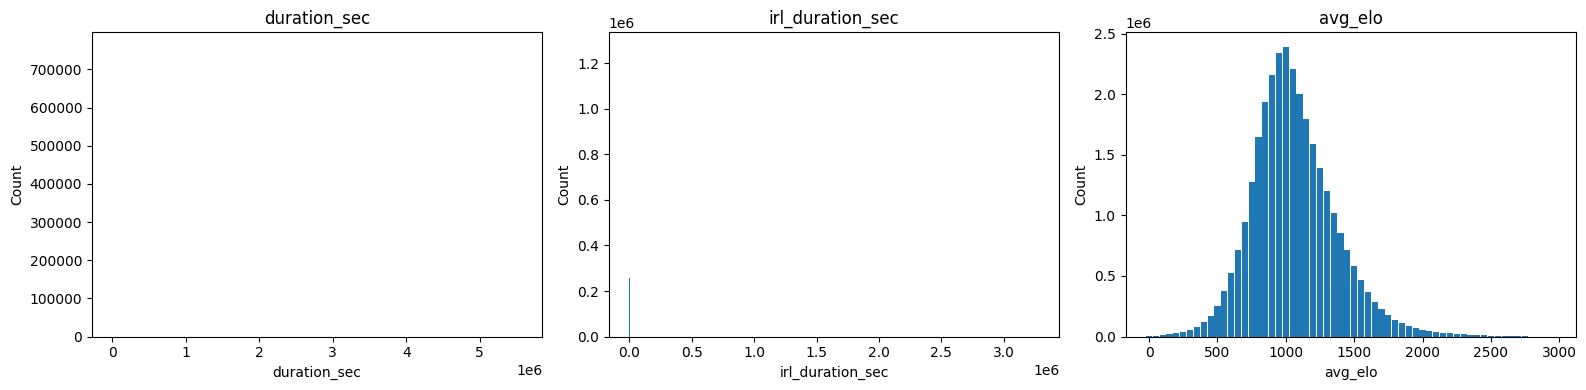

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (label, df) in zip(axes, hist_data.items()):
    ax.bar(df["bin"], df["cnt"], width=df["bin"].diff().median() * 0.9)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_duration_histogram.png", dpi=150)
plt.show()
plt.close()

In [49]:
HIST_DEFS_PLAYERS = [
    ("players_raw", "old_rating", "old_rating", 50),
    ("players_raw", "new_rating", "new_rating", 50),
    ("players_raw", "match_rating_diff", "match_rating_diff", 5),
    ("players_raw", "feudal_age_uptime", "feudal_age_uptime", 10),
    ("players_raw", "castle_age_uptime", "castle_age_uptime", 10),
    ("players_raw", "imperial_age_uptime", "imperial_age_uptime", 10),
]

for table, expr, label, bin_width in HIST_DEFS_PLAYERS:
    sql = f"""
SELECT
    FLOOR({expr} / {bin_width}) * {bin_width} AS bin,
    COUNT(*) AS cnt
FROM {table}
WHERE {expr} IS NOT NULL
GROUP BY bin
ORDER BY bin
"""
    df = con.execute(sql).df()
    hist_data[label] = df
    sql_queries[f"hist_{label}"] = sql.strip()

In [50]:
print("Data feeding players numeric histograms:")
for table, expr, label, _ in HIST_DEFS_PLAYERS:
    df = hist_data[label]
    print(f"\n  {label}: {len(df)} bins, first 5:")
    print(f"  {df.head(5).to_string(index=False)}")
    print(f"  ...last 5:")
    print(f"  {df.tail(5).to_string(index=False)}")

Data feeding players numeric histograms:

  old_rating: 61 bins, first 5:
    bin   cnt
  0.0 17793
 50.0 16409
100.0 23445
150.0 35033
200.0 51804
  ...last 5:
     bin  cnt
2800.0 2134
2850.0  970
2900.0  599
2950.0  205
3000.0   80

  new_rating: 62 bins, first 5:
    bin   cnt
-50.0   828
  0.0 17134
 50.0 16492
100.0 23625
150.0 35271
  ...last 5:
     bin  cnt
2800.0 2138
2850.0  978
2900.0  595
2950.0  208
3000.0   84

  match_rating_diff: 714 bins, first 5:
      bin  cnt
-2185.0    1
-2145.0    1
-2055.0    1
-1980.0    1
-1960.0    1
  ...last 5:
     bin  cnt
1955.0    1
1980.0    1
2050.0    1
2140.0    1
2185.0    1

  feudal_age_uptime: 411 bins, first 5:
    bin  cnt
100.0    2
120.0    2
130.0   31
140.0   13
150.0    6
  ...last 5:
      bin  cnt
 5190.0    1
 5290.0    1
 5630.0    1
10760.0    1
12550.0    1

  castle_age_uptime: 537 bins, first 5:
    bin  cnt
300.0    1
340.0    2
350.0    4
360.0    3
380.0    3
  ...last 5:
      bin  cnt
 7290.0    1
 7370.0    

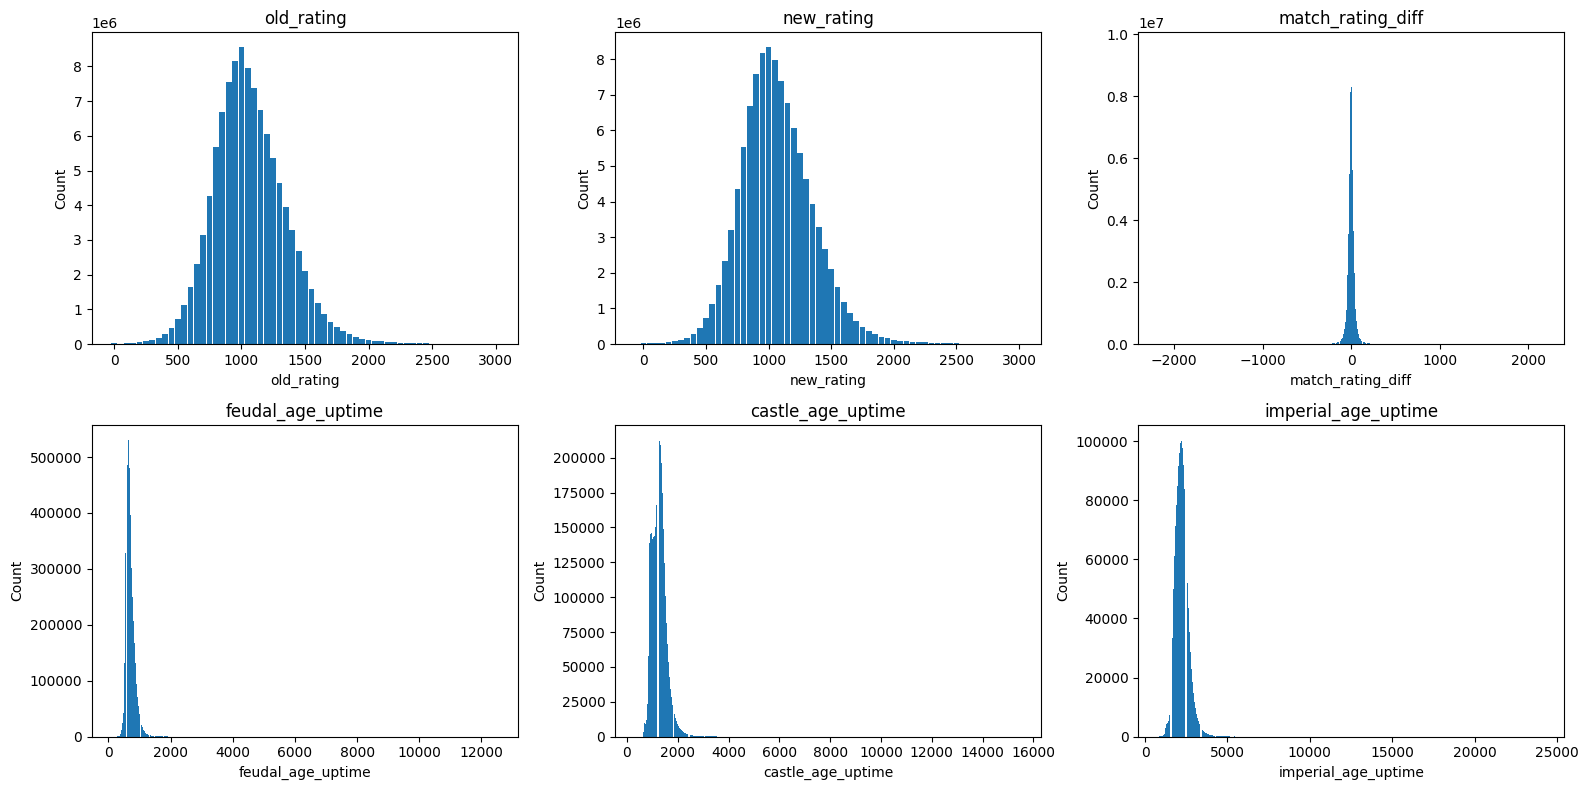

In [51]:
player_hist_labels = [
    "old_rating", "new_rating", "match_rating_diff",
    "feudal_age_uptime", "castle_age_uptime", "imperial_age_uptime",
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, label in zip(axes.flat, player_hist_labels):
    df = hist_data[label]
    bw = df["bin"].diff().median()
    if pd.isna(bw) or bw == 0:
        bw = 1
    ax.bar(df["bin"], df["cnt"], width=float(bw) * 0.9)
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("Count")

plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_numeric_histograms.png", dpi=150)
plt.show()
plt.close()

### F.5 Numeric boxplots (from precomputed percentiles)

Use already-computed percentile data for boxplot rendering.

In [52]:
all_numeric_stats = {
    s["label"]: s
    for s in numeric_stats_matches + numeric_stats_players
}
box_cols = [
    "duration_sec", "irl_duration_sec", "avg_elo",
    "old_rating", "new_rating", "match_rating_diff",
    "feudal_age_uptime", "castle_age_uptime", "imperial_age_uptime",
]

In [53]:
print("Data feeding numeric boxplots (precomputed percentiles):")
for col in box_cols:
    s = all_numeric_stats[col]
    print(
        f"  {col}: p05={s['p05']}, p25={s['p25']}, p50={s['p50']}, "
        f"p75={s['p75']}, p95={s['p95']}"
    )

Data feeding numeric boxplots (precomputed percentiles):
  duration_sec: p05=285.6, p25=1824.1, p50=2619.7, p75=3292.9, p95=4714.1
  irl_duration_sec: p05=168.0, p25=1073.0, p50=1541.0, p75=1937.0, p95=2773.0
  avg_elo: p05=637.0, p25=886.5, p50=1055.0, p75=1260.5, p95=1630.0
  old_rating: p05=665.0, p25=900.0, p50=1066.0, p75=1263.0, p95=1580.0
  new_rating: p05=663.0, p25=899.0, p50=1067.0, p75=1263.0, p95=1581.0
  match_rating_diff: p05=-59.0, p25=-17.0, p50=0.0, p75=17.0, p95=59.0
  feudal_age_uptime: p05=535.11, p25=611.52, p50=680.22, p75=774.38, p95=962.59
  castle_age_uptime: p05=889.07, p25=1069.66, p50=1262.91, p75=1427.34, p95=1752.13
  imperial_age_uptime: p05=1681.08, p25=1966.16, p50=2208.64, p75=2462.87, p95=2932.96


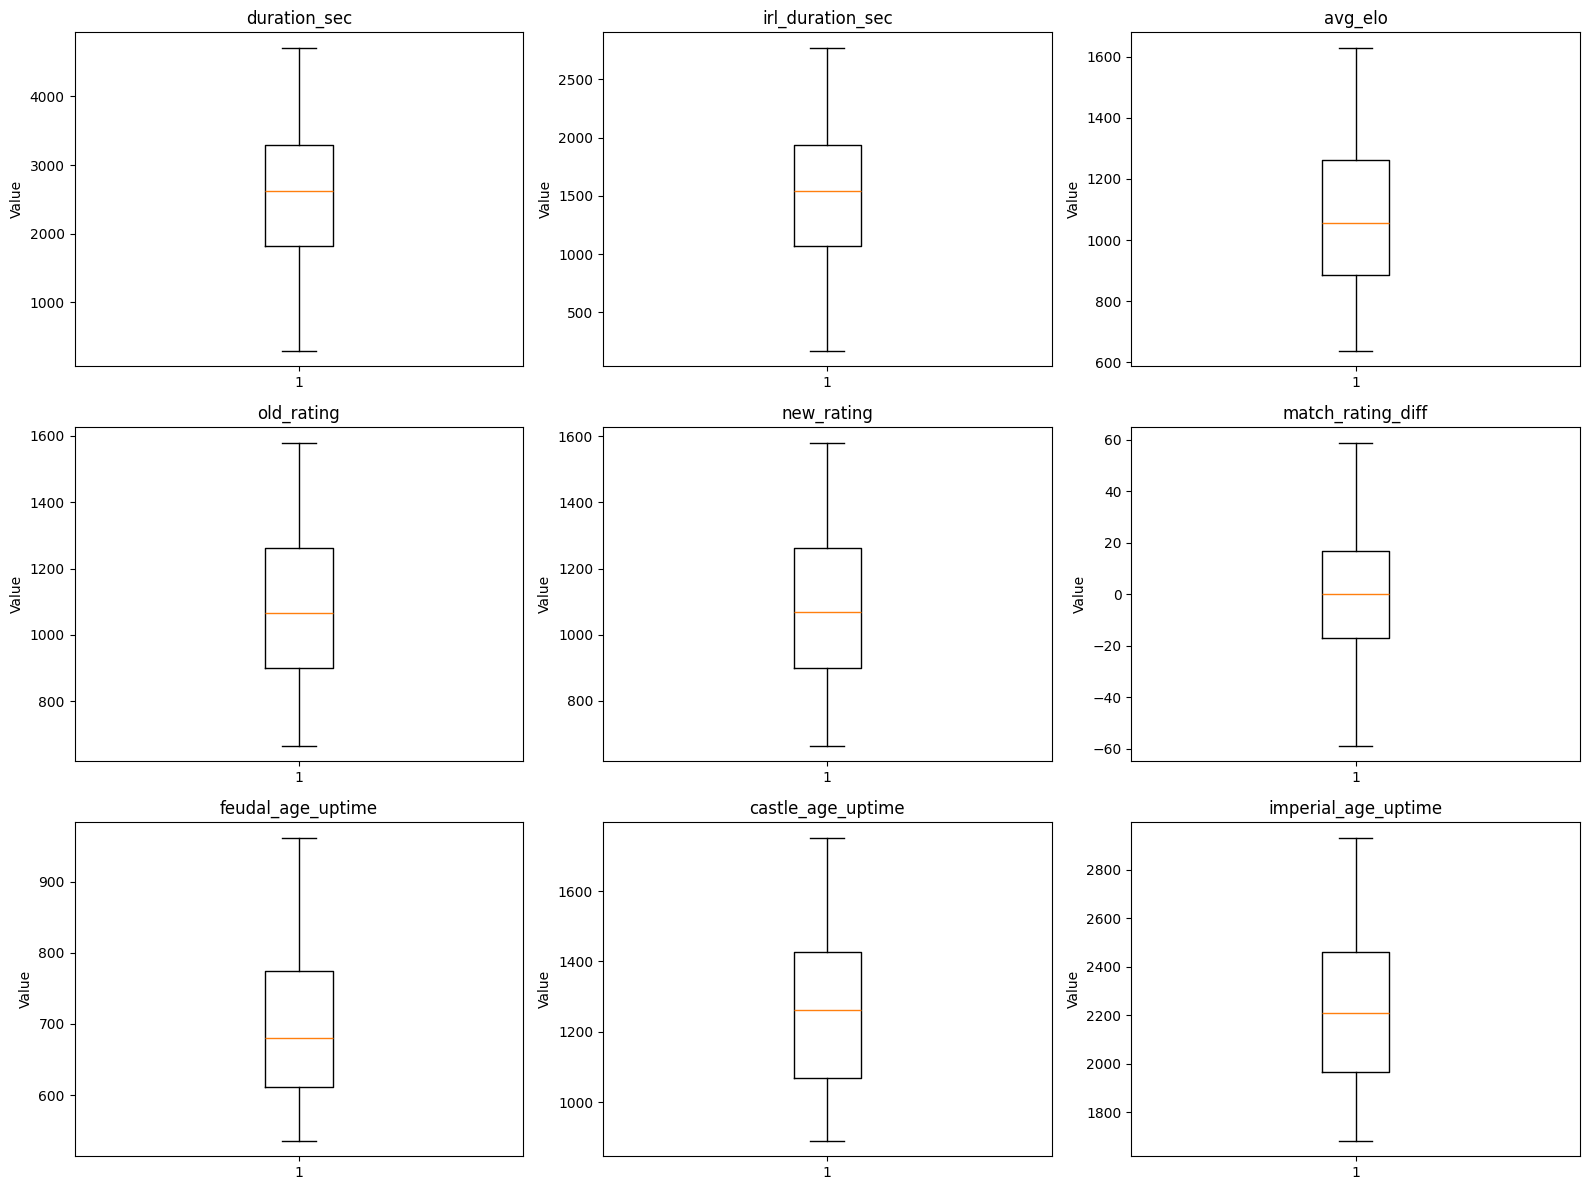

In [54]:
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
for ax, col in zip(axes.flat, box_cols):
    s = all_numeric_stats[col]
    if s["p25"] is None or s["p75"] is None:
        ax.set_title(f"{col} (no data)")
        continue
    bp_data = {
        "med": s["p50"],
        "q1": s["p25"],
        "q3": s["p75"],
        "whislo": s["p05"],
        "whishi": s["p95"],
    }
    ax.bxp([bp_data], showfliers=False)
    ax.set_title(col)
    ax.set_ylabel("Value")

plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_numeric_boxplots.png", dpi=150)
plt.show()
plt.close()

### F.6 IQR-based outlier counts

Outlier detection per EDA Manual Section 3.1.
IQR = p75 - p25. Lower fence = p25 - 1.5 * IQR. Upper fence = p75 + 1.5 * IQR.
Factor 1.5 is Tukey's standard (Tukey 1977, Exploratory Data Analysis, p. 44). [I7]

In [55]:
def compute_iqr_outliers(con, table, expr, label, p25, p75):
    iqr = p75 - p25
    if iqr == 0:
        return {"label": label, "outlier_low": 0, "outlier_high": 0,
                "outlier_total": 0, "outlier_pct": 0.0,
                "denominator": "pct_of_non_null_values",
                "lower_fence": p25, "upper_fence": p75,
                "note": "IQR=0; fence-based detection not meaningful"}
    lower_fence = p25 - 1.5 * iqr
    upper_fence = p75 + 1.5 * iqr
    sql = f"""
    SELECT
        COUNT(*) FILTER (WHERE {expr} < {lower_fence}) AS outlier_low,
        COUNT(*) FILTER (WHERE {expr} > {upper_fence}) AS outlier_high,
        COUNT(*) FILTER (WHERE {expr} IS NOT NULL)     AS n_nonnull
    FROM {table}
    """
    row = con.execute(sql).df().iloc[0]
    total = int(row["outlier_low"]) + int(row["outlier_high"])
    nonnull = int(row["n_nonnull"])
    return {
        "label": label,
        "outlier_low": int(row["outlier_low"]),
        "outlier_high": int(row["outlier_high"]),
        "outlier_total": total,
        "outlier_pct": round(100.0 * total / nonnull, 2) if nonnull > 0 else 0.0,
        "denominator": "pct_of_non_null_values",
        "lower_fence": round(lower_fence, 2),
        "upper_fence": round(upper_fence, 2),
    }

outlier_counts_matches = []
for table, expr, label in MATCHES_NUMERIC_DEFS:
    stats = next(s for s in numeric_stats_matches if s["label"] == label)
    result = compute_iqr_outliers(con, table, expr, label, stats["p25"], stats["p75"])
    outlier_counts_matches.append(result)
    print(f"{label}: {result['outlier_total']:,} outliers ({result['outlier_pct']}%)")

outlier_counts_players = []
for table, expr, label in PLAYERS_NUMERIC_DEFS:
    stats = next(s for s in numeric_stats_players if s["label"] == label)
    result = compute_iqr_outliers(con, table, expr, label, stats["p25"], stats["p75"])
    outlier_counts_players.append(result)
    print(f"{label}: {result['outlier_total']:,} outliers ({result['outlier_pct']}%)")

findings["outlier_counts_matches"] = outlier_counts_matches
findings["outlier_counts_players"] = outlier_counts_players
findings["outlier_counts_note"] = (
    "outlier_pct is percentage of non-NULL values, not percentage of all rows. "
    "For high-NULL columns (e.g., feudal_age_uptime at 87% NULL), these differ "
    "substantially. See 'denominator' field in each entry."
)

duration_sec: 715,749 outliers (2.33%)
irl_duration_sec: 715,749 outliers (2.33%)
avg_elo: 779,388 outliers (2.54%)
team_0_elo: 793,804 outliers (2.59%)
team_1_elo: 777,943 outliers (2.53%)
raw_match_type: 1,211,728 outliers (3.95%)
patch: 0 outliers (0.0%)


old_rating: 1,933,860 outliers (1.8%)
new_rating: 1,916,076 outliers (1.78%)


match_rating_diff: 8,259,845 outliers (7.67%)
feudal_age_uptime: 433,340 outliers (3.12%)
castle_age_uptime: 258,202 outliers (1.99%)
imperial_age_uptime: 202,456 outliers (2.21%)


### F.7 Sentinel value detection: team ELO fields

`team_0_elo` and `team_1_elo` show min=-1.0. Negative ELO is likely
a sentinel for "unranked/unknown". Quantify and enumerate.

In [56]:
sql_elo_sentinel = """
SELECT
    COUNT(*) FILTER (WHERE team_0_elo < 0)   AS team_0_elo_neg,
    COUNT(*) FILTER (WHERE team_1_elo < 0)   AS team_1_elo_neg,
    COUNT(*)                                  AS total_rows
FROM matches_raw
"""
sql_queries["elo_sentinel_counts"] = sql_elo_sentinel.strip()
elo_sentinel_row = con.execute(sql_elo_sentinel).df().iloc[0]

sql_elo_neg_distinct = """
SELECT DISTINCT team_0_elo AS elo_val FROM matches_raw WHERE team_0_elo < 0
UNION
SELECT DISTINCT team_1_elo AS elo_val FROM matches_raw WHERE team_1_elo < 0
ORDER BY elo_val
"""
sql_queries["elo_neg_distinct_values"] = sql_elo_neg_distinct.strip()
elo_neg_distinct = con.execute(sql_elo_neg_distinct).df()

findings["elo_sentinel_counts"] = {
    "team_0_elo_negative": int(elo_sentinel_row["team_0_elo_neg"]),
    "team_1_elo_negative": int(elo_sentinel_row["team_1_elo_neg"]),
    "total_rows": int(elo_sentinel_row["total_rows"]),
    "team_0_pct": round(100.0 * int(elo_sentinel_row["team_0_elo_neg"]) / int(elo_sentinel_row["total_rows"]), 2),
    "team_1_pct": round(100.0 * int(elo_sentinel_row["team_1_elo_neg"]) / int(elo_sentinel_row["total_rows"]), 2),
}
findings["elo_negative_distinct_values"] = elo_neg_distinct["elo_val"].tolist()
print("ELO sentinel:", findings["elo_sentinel_counts"])
print("Distinct negative ELO values:", findings["elo_negative_distinct_values"])

ELO sentinel: {'team_0_elo_negative': 34, 'team_1_elo_negative': 39, 'total_rows': 30690651, 'team_0_pct': 0.0, 'team_1_pct': 0.0}
Distinct negative ELO values: [-1.0]


### F.9 ELO sentinel-excluded descriptive stats

Parallel stats for team_0_elo and team_1_elo excluding the -1.0 sentinel.
ELO=0 rows (4,824 for team_0_elo, 192 for team_1_elo) are NOT excluded --
only the -1.0 sentinel (unranked marker) is excluded. ELO=0 may be valid.

In [57]:
for elo_col in ["team_0_elo", "team_1_elo"]:
    sql = f"""
SELECT
    COUNT({elo_col}) AS n_nonnull,
    COUNT(*) - COUNT({elo_col}) AS n_null,
    SUM(CASE WHEN {elo_col} = 0 THEN 1 ELSE 0 END) AS n_zero,
    MIN({elo_col}) AS min_val,
    MAX({elo_col}) AS max_val,
    ROUND(AVG({elo_col}), 2) AS mean_val,
    ROUND(MEDIAN({elo_col}), 2) AS median_val,
    ROUND(STDDEV({elo_col}), 2) AS stddev_val,
    ROUND(PERCENTILE_CONT(0.05) WITHIN GROUP (ORDER BY {elo_col}), 2) AS p05,
    ROUND(PERCENTILE_CONT(0.25) WITHIN GROUP (ORDER BY {elo_col}), 2) AS p25,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY {elo_col}), 2) AS p50,
    ROUND(PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY {elo_col}), 2) AS p75,
    ROUND(PERCENTILE_CONT(0.95) WITHIN GROUP (ORDER BY {elo_col}), 2) AS p95
FROM matches_raw
WHERE {elo_col} != -1.0
-- Note: ELO=0 rows (4,824 for team_0_elo, 192 for team_1_elo) are NOT excluded here;
-- only the -1.0 sentinel (unranked marker) is excluded. ELO=0 may represent valid
-- entries and requires separate investigation if needed.
"""
    df = con.execute(sql).df()
    rec = df.iloc[0].to_dict()
    rec = {k: float(v) if pd.notna(v) else None for k, v in rec.items()}
    findings[f"{elo_col}_stats_no_sentinel"] = rec
    sql_queries[f"numeric_matches_{elo_col}_no_sentinel"] = sql.strip()
    print(f"\n=== {elo_col} (sentinel -1.0 excluded) ===")
    print(df.to_string(index=False))


=== team_0_elo (sentinel -1.0 excluded) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
  30690617       0  4824.0      0.0   3038.0   1082.67      1051.5      312.31 625.5 881.5 1051.5 1258.0 1629.0



=== team_1_elo (sentinel -1.0 excluded) ===
 n_nonnull  n_null  n_zero  min_val  max_val  mean_val  median_val  stddev_val   p05   p25    p50    p75    p95
  30690612       0   192.0      0.0   3045.0   1092.53      1058.0      309.32 646.0 890.5 1058.0 1264.0 1636.0


## Section G: Temporal range

`started_timestamp` is TIMESTAMP WITH TIME ZONE (native DuckDB).
Cross-validate against 01_01_01 filename-derived range.

In [58]:
TEMPORAL_SQL = """
SELECT
    MIN(started_timestamp) AS earliest,
    MAX(started_timestamp) AS latest,
    COUNT(DISTINCT DATE_TRUNC('month', started_timestamp)) AS distinct_months,
    COUNT(DISTINCT DATE_TRUNC('week', started_timestamp)) AS distinct_weeks
FROM matches_raw
"""
sql_queries["temporal_range"] = TEMPORAL_SQL

In [59]:
temporal_df = con.execute(TEMPORAL_SQL).df()
print(temporal_df.to_string(index=False))

                 earliest                    latest  distinct_months  distinct_weeks
2022-08-29 02:00:34+02:00 2026-02-06 07:32:24+01:00               42             175


In [60]:
findings["temporal_range"] = {
    "earliest": str(temporal_df["earliest"].iloc[0]),
    "latest": str(temporal_df["latest"].iloc[0]),
    "distinct_months": int(temporal_df["distinct_months"].iloc[0]),
    "distinct_weeks": int(temporal_df["distinct_weeks"].iloc[0]),
}

In [61]:
MONTHLY_SQL = """
SELECT
    DATE_TRUNC('month', started_timestamp) AS month,
    COUNT(*) AS match_count
FROM matches_raw
WHERE started_timestamp IS NOT NULL
GROUP BY month
ORDER BY month
"""
sql_queries["monthly_match_counts"] = MONTHLY_SQL

In [62]:
monthly_df = con.execute(MONTHLY_SQL).df()
print(f"Monthly data: {len(monthly_df)} months")
print(monthly_df.head(10).to_string(index=False))

Monthly data: 42 months
                    month  match_count
2022-08-01 00:00:00+02:00         4996
2022-09-01 00:00:00+02:00        60573
2022-10-01 00:00:00+02:00        70872
2022-11-01 00:00:00+01:00        85772
2022-12-01 00:00:00+01:00       112938
2023-01-01 00:00:00+01:00       165285
2023-02-01 00:00:00+01:00       319752
2023-03-01 00:00:00+01:00       714232
2023-04-01 00:00:00+02:00      1092681
2023-05-01 00:00:00+02:00      1049710


In [63]:
print(f"Monthly match counts: {len(monthly_df)} months")
print(monthly_df.to_string(index=False))

Monthly match counts: 42 months
                    month  match_count
2022-08-01 00:00:00+02:00         4996
2022-09-01 00:00:00+02:00        60573
2022-10-01 00:00:00+02:00        70872
2022-11-01 00:00:00+01:00        85772
2022-12-01 00:00:00+01:00       112938
2023-01-01 00:00:00+01:00       165285
2023-02-01 00:00:00+01:00       319752
2023-03-01 00:00:00+01:00       714232
2023-04-01 00:00:00+02:00      1092681
2023-05-01 00:00:00+02:00      1049710
2023-06-01 00:00:00+02:00       931837
2023-07-01 00:00:00+02:00       955105
2023-08-01 00:00:00+02:00       637984
2023-09-01 00:00:00+02:00       879154
2023-10-01 00:00:00+02:00       933730
2023-11-01 00:00:00+01:00       939783
2023-12-01 00:00:00+01:00       966203
2024-01-01 00:00:00+01:00       982839
2024-02-01 00:00:00+01:00       943190
2024-03-01 00:00:00+01:00      1074021
2024-04-01 00:00:00+02:00      1015708
2024-05-01 00:00:00+02:00       885853
2024-06-01 00:00:00+02:00       909510
2024-07-01 00:00:00+02:00       

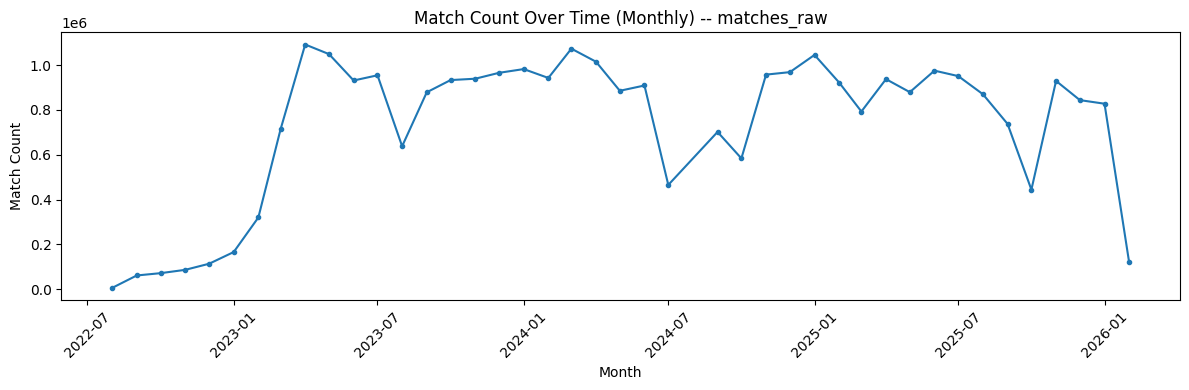

In [64]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly_df["month"], monthly_df["match_count"], marker="o", markersize=3)
ax.set_xlabel("Month")
ax.set_ylabel("Match Count")
ax.set_title("Match Count Over Time (Monthly) -- matches_raw")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(plots_dir / "01_02_04_match_count_over_time.png", dpi=150)
plt.show()
plt.close()

## Section H: game_id join integrity

Orphan detection between tables and players-per-match distribution.

In [65]:
ORPHAN_SQL = """
SELECT
    'players_without_match' AS check_name,
    COUNT(DISTINCT p.game_id) AS cnt
FROM players_raw p
LEFT JOIN matches_raw m ON p.game_id = m.game_id
WHERE m.game_id IS NULL
UNION ALL
SELECT
    'matches_without_players' AS check_name,
    COUNT(DISTINCT m.game_id) AS cnt
FROM matches_raw m
LEFT JOIN players_raw p ON m.game_id = p.game_id
WHERE p.game_id IS NULL
"""
sql_queries["orphan_detection"] = ORPHAN_SQL

In [66]:
orphan_df = con.execute(ORPHAN_SQL).df()
print(orphan_df.to_string(index=False))

             check_name    cnt
  players_without_match      0
matches_without_players 212890


In [67]:
findings["join_integrity_orphans"] = orphan_df.to_dict(orient="records")

In [68]:
PPM_SQL = """
SELECT
    player_count,
    COUNT(*) AS match_count,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS pct
FROM (
    SELECT game_id, COUNT(*) AS player_count
    FROM players_raw
    GROUP BY game_id
)
GROUP BY player_count
ORDER BY player_count
"""
sql_queries["players_per_match"] = PPM_SQL

In [69]:
ppm_df = con.execute(PPM_SQL).df()
print(ppm_df.to_string(index=False))

 player_count  match_count   pct
            1           39  0.00
            2     18438769 60.50
            3          349  0.00
            4      5027632 16.50
            5          327  0.00
            6      2723856  8.94
            7          651  0.00
            8      4286138 14.06


In [70]:
findings["players_per_match"] = ppm_df.to_dict(orient="records")

## Section H.2: Duplicate Row Detection

EDA Manual Section 3.2 requires duplicate row count and percentage.
matches_raw: duplicates by game_id.
players_raw: duplicates by (game_id, profile_id) composite.
COALESCE used for profile_id because it has 1,185 NULLs in players_raw;
NULL || anything = NULL in SQL, which would silently exclude those rows.

In [71]:
DUPE_MATCHES_SQL = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT CAST(game_id AS VARCHAR)) AS distinct_game_ids,
    COUNT(*) - COUNT(DISTINCT CAST(game_id AS VARCHAR)) AS duplicate_rows
FROM matches_raw
"""
sql_queries["duplicate_check_matches"] = DUPE_MATCHES_SQL
dupe_m = con.execute(DUPE_MATCHES_SQL).df()
print("matches_raw duplicate check:")
print(dupe_m.to_string(index=False))
findings["duplicate_check_matches"] = {k: int(v) for k, v in dupe_m.iloc[0].to_dict().items()}

matches_raw duplicate check:
 total_rows  distinct_game_ids  duplicate_rows
   30690651           30690651               0


In [72]:
DUPE_PLAYERS_SQL = """
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT CAST(game_id AS VARCHAR) || '_' || COALESCE(CAST(profile_id AS VARCHAR), '__NULL__'))
        AS distinct_game_player_pairs,
    COUNT(*) - COUNT(DISTINCT CAST(game_id AS VARCHAR) || '_' || COALESCE(CAST(profile_id AS VARCHAR), '__NULL__'))
        AS duplicate_rows
FROM players_raw
"""
sql_queries["duplicate_check_players"] = DUPE_PLAYERS_SQL
dupe_p = con.execute(DUPE_PLAYERS_SQL).df()
print("players_raw duplicate check:")
print(dupe_p.to_string(index=False))
findings["duplicate_check_players"] = {k: int(v) for k, v in dupe_p.iloc[0].to_dict().items()}

players_raw duplicate check:
 total_rows  distinct_game_player_pairs  duplicate_rows
  107627584                   107627095             489


## Section I: Dead/constant/near-constant field detection

Uniqueness ratio for all columns. Flag cardinality = 1 (constant)
or uniqueness ratio < 0.001 (near-constant, EDA Manual Section 3.3).
NULL deflation note: for flagged columns with >50% NULL,
also report non-NULL uniqueness ratio.

In [73]:
MATCHES_COLS_ALL = [
    "map", "started_timestamp", "duration", "irl_duration", "game_id",
    "avg_elo", "num_players", "team_0_elo", "team_1_elo",
    "replay_enhanced", "leaderboard", "mirror", "patch",
    "raw_match_type", "game_type", "game_speed", "starting_age",
    "filename",
]

uniqueness_rows_m = []
for col in MATCHES_COLS_ALL:
    sql = f"""
SELECT
    '{col}' AS column_name,
    COUNT(DISTINCT {col}) AS cardinality,
    COUNT(*) AS total_rows,
    COUNT({col}) AS nonnull_rows,
    ROUND(COUNT(DISTINCT {col})::DOUBLE / COUNT(*)::DOUBLE, 6) AS uniqueness_ratio,
    ROUND(COUNT(DISTINCT {col})::DOUBLE / NULLIF(COUNT({col}), 0)::DOUBLE, 6) AS nonnull_uniqueness_ratio
FROM matches_raw
"""
    df = con.execute(sql).df()
    uniqueness_rows_m.append(df.iloc[0].to_dict())
    sql_queries[f"uniqueness_matches_{col}"] = sql.strip()

In [74]:
uniq_m_df = pd.DataFrame(uniqueness_rows_m)
print("matches_raw uniqueness:\n")
print(uniq_m_df.to_string(index=False))

matches_raw uniqueness:

      column_name  cardinality  total_rows  nonnull_rows  uniqueness_ratio  nonnull_uniqueness_ratio
              map           93    30690651      30690651          0.000003                  0.000003
started_timestamp     24385989    30690651      30690651          0.794574                  0.794574
         duration        13164    30690651      30690651          0.000429                  0.000429
     irl_duration        13164    30690651      30690651          0.000429                  0.000429
          game_id     30690651    30690651      30690651          1.000000                  1.000000
          avg_elo        22432    30690651      30690651          0.000731                  0.000731
      num_players            8    30690651      30690651          0.000000                  0.000000
       team_0_elo        12037    30690651      30690651          0.000392                  0.000392
       team_1_elo        11587    30690651      30690651          

In [75]:
PLAYERS_COLS_ALL = [
    "winner", "game_id", "team", "feudal_age_uptime",
    "castle_age_uptime", "imperial_age_uptime", "old_rating",
    "new_rating", "match_rating_diff", "replay_summary_raw",
    "profile_id", "civ", "opening", "filename",
]

uniqueness_rows_p = []
for col in PLAYERS_COLS_ALL:
    sql = f"""
SELECT
    '{col}' AS column_name,
    COUNT(DISTINCT {col}) AS cardinality,
    COUNT(*) AS total_rows,
    COUNT({col}) AS nonnull_rows,
    ROUND(COUNT(DISTINCT {col})::DOUBLE / COUNT(*)::DOUBLE, 6) AS uniqueness_ratio,
    ROUND(COUNT(DISTINCT {col})::DOUBLE / NULLIF(COUNT({col}), 0)::DOUBLE, 6) AS nonnull_uniqueness_ratio
FROM players_raw
"""
    df = con.execute(sql).df()
    uniqueness_rows_p.append(df.iloc[0].to_dict())
    sql_queries[f"uniqueness_players_{col}"] = sql.strip()

In [76]:
uniq_p_df = pd.DataFrame(uniqueness_rows_p)
print("players_raw uniqueness:\n")
print(uniq_p_df.to_string(index=False))

players_raw uniqueness:

        column_name  cardinality  total_rows  nonnull_rows  uniqueness_ratio  nonnull_uniqueness_ratio
             winner            2   107627584     107627584          0.000000                  0.000000
            game_id     30477761   107627584     107627584          0.283178                  0.283178
               team            2   107627584     107627584          0.000000                  0.000000
  feudal_age_uptime       978519   107627584      13901136          0.009092                  0.070391
  castle_age_uptime      1564065   107627584      12985753          0.014532                  0.120445
imperial_age_uptime      1924964   107627584       9158680          0.017885                  0.210179
         old_rating         3032   107627584     107627584          0.000028                  0.000028
         new_rating         3039   107627584     107627584          0.000028                  0.000028
  match_rating_diff        24919   107627584    

In [77]:
dead_constant = []
near_constant_low_cardinality = []
near_constant_ratio_flagged = []

# [I7] Empirical threshold: max categorical cardinality in this dataset is 93 (map);
# min continuous cardinality is 3,032 (old_rating). Threshold of 100 cleanly separates groups.
# (civ cardinality=50 is correctly included as categorical under this threshold.)
# Key names aligned with aoe2companion plan for cross-dataset comparability.
NEAR_CONSTANT_CARDINALITY_THRESHOLD = 100

for row in uniqueness_rows_m + uniqueness_rows_p:
    card = int(row["cardinality"])
    ratio = float(row["uniqueness_ratio"])
    if card == 1:
        dead_constant.append(row)
    elif card < NEAR_CONSTANT_CARDINALITY_THRESHOLD and ratio < 0.001:
        near_constant_low_cardinality.append(row)
    elif ratio < 0.001:
        near_constant_ratio_flagged.append(row)

print(f"\nDead/constant fields (cardinality=1): {len(dead_constant)}")
for r in dead_constant:
    print(f"  {r['column_name']}: cardinality={r['cardinality']}")

print(f"\nNear-constant low-cardinality (cardinality < {NEAR_CONSTANT_CARDINALITY_THRESHOLD} AND ratio < 0.001): {len(near_constant_low_cardinality)}")
for r in near_constant_low_cardinality:
    print(f"  {r['column_name']}: cardinality={r['cardinality']}, ratio={r['uniqueness_ratio']}")

print(f"\nRatio-flagged (cardinality >= {NEAR_CONSTANT_CARDINALITY_THRESHOLD}, ratio < 0.001 due to large N): {len(near_constant_ratio_flagged)}")
for r in near_constant_ratio_flagged:
    print(f"  {r['column_name']}: cardinality={r['cardinality']}, ratio={r['uniqueness_ratio']}")
    print(f"    -> NOT near-constant; ratio is low only because N={r['total_rows']:,}")


Dead/constant fields (cardinality=1): 2
  game_type: cardinality=1
  game_speed: cardinality=1

Near-constant low-cardinality (cardinality < 100 AND ratio < 0.001): 12
  map: cardinality=93, ratio=3e-06
  num_players: cardinality=8, ratio=0.0
  replay_enhanced: cardinality=2, ratio=0.0
  leaderboard: cardinality=4, ratio=0.0
  mirror: cardinality=2, ratio=0.0
  patch: cardinality=19, ratio=1e-06
  raw_match_type: cardinality=8, ratio=0.0
  starting_age: cardinality=2, ratio=0.0
  winner: cardinality=2, ratio=0.0
  team: cardinality=2, ratio=0.0
  civ: cardinality=50, ratio=0.0
  opening: cardinality=10, ratio=0.0

Ratio-flagged (cardinality >= 100, ratio < 0.001 due to large N): 10
  duration: cardinality=13164, ratio=0.000429
    -> NOT near-constant; ratio is low only because N=30,690,651
  irl_duration: cardinality=13164, ratio=0.000429
    -> NOT near-constant; ratio is low only because N=30,690,651
  avg_elo: cardinality=22432, ratio=0.000731
    -> NOT near-constant; ratio is lo

In [78]:
findings["uniqueness_matches"] = uniqueness_rows_m
findings["uniqueness_players"] = uniqueness_rows_p
findings["dead_constant_fields"] = dead_constant
findings["near_constant_low_cardinality"] = near_constant_low_cardinality
findings["near_constant_ratio_flagged"] = near_constant_ratio_flagged
findings["near_constant_detection_note"] = {
    "cardinality_threshold": NEAR_CONSTANT_CARDINALITY_THRESHOLD,
    "justification": (
        "EDA Manual Section 3.3 uses uniqueness_ratio < 0.001 as a starting point. "
        "On a 30M/107M row dataset, this ratio flags continuous numerics with "
        "thousands of distinct values. Threshold of 100 separates genuinely "
        "low-cardinality columns (max categorical: map at 93) from continuous numerics "
        "(min: old_rating at 3,032). Columns flagged only by ratio are documented "
        "as 'near_constant_ratio_flagged' and are NOT near-constant."
    ),
}

## Section K: Field temporal classification

Classify every column by availability at prediction time.
Categories: identifier | pre_game | in_game | post_game | target | constant | meta | deferred
Invariant #3: any field classified as post_game or target is excluded from
pre-game feature engineering. Fields classified as 'deferred' require
empirical verification before use.

In [79]:
field_classification = {
    "classification_status": "preliminary",
    "formal_boundary_deferred_to": "Phase 02 (Feature Engineering)",
    "fields": [
        # matches_raw (18 columns)
        {"table": "matches_raw", "column": "game_id",          "classification": "identifier", "rationale": "Join key"},
        {"table": "matches_raw", "column": "map",              "classification": "pre_game",   "rationale": "Known at match creation"},
        {"table": "matches_raw", "column": "started_timestamp","classification": "pre_game",   "rationale": "Match start time"},
        {"table": "matches_raw", "column": "num_players",      "classification": "pre_game",   "rationale": "Lobby size known at match start"},
        {"table": "matches_raw", "column": "avg_elo",          "classification": "pre_game",   "rationale": "Computed from pre-match ratings"},
        {"table": "matches_raw", "column": "team_0_elo",       "classification": "pre_game",   "rationale": "Team 0 pre-match rating; sentinel -1.0 = unranked"},
        {"table": "matches_raw", "column": "team_1_elo",       "classification": "pre_game",   "rationale": "Team 1 pre-match rating; sentinel -1.0 = unranked"},
        {"table": "matches_raw", "column": "leaderboard",      "classification": "pre_game",   "rationale": "Ladder type selected before match"},
        {"table": "matches_raw", "column": "game_type",        "classification": "constant",   "rationale": "Cardinality=1 across entire dataset"},
        {"table": "matches_raw", "column": "game_speed",       "classification": "constant",   "rationale": "Cardinality=1 across entire dataset"},
        {"table": "matches_raw", "column": "starting_age",     "classification": "pre_game",   "rationale": "Game setting at lobby; near-constant (cardinality=2: 'dark' 30,690,632 rows vs 'standard' 19 rows)"},
        {"table": "matches_raw", "column": "mirror",           "classification": "pre_game",   "rationale": "Derivable from civ selections at match start"},
        {"table": "matches_raw", "column": "patch",            "classification": "pre_game",   "rationale": "Game version known at match time"},
        {"table": "matches_raw", "column": "raw_match_type",   "classification": "pre_game",   "rationale": "Match type determined before match"},
        {"table": "matches_raw", "column": "replay_enhanced",  "classification": "meta",       "rationale": "Data quality/source flag"},
        {"table": "matches_raw", "column": "duration",         "classification": "post_game",  "rationale": "Only known after match ends"},
        {"table": "matches_raw", "column": "irl_duration",     "classification": "post_game",  "rationale": "Only known after match ends"},
        {"table": "matches_raw", "column": "filename",         "classification": "meta",       "rationale": "Provenance column (Invariant I10)"},
        # players_raw (14 columns)
        {"table": "players_raw", "column": "game_id",          "classification": "identifier", "rationale": "Join key"},
        {"table": "players_raw", "column": "profile_id",       "classification": "identifier", "rationale": "Player identifier"},
        {"table": "players_raw", "column": "winner",           "classification": "target",     "rationale": "Prediction target (Invariant #3)"},
        {"table": "players_raw", "column": "team",             "classification": "pre_game",   "rationale": "Team assignment known at match start"},
        {"table": "players_raw", "column": "civ",              "classification": "pre_game",   "rationale": "Civilization selected at match start"},
        {"table": "players_raw", "column": "old_rating",       "classification": "pre_game",   "rationale": "Player rating before match (authoritative pre-game signal)"},
        {"table": "players_raw", "column": "new_rating",       "classification": "post_game",  "rationale": "LEAKAGE -- player rating after match (Invariant #3 violation if used as feature)"},
        {"table": "players_raw", "column": "match_rating_diff","classification": "deferred",   "rationale": "Leakage status unknown -- could be (new_rating - old_rating) = post_game, or (player_elo - opponent_elo) = pre_game. Requires empirical test: SELECT COUNT(*) FROM players_raw WHERE ABS(match_rating_diff - (new_rating - old_rating)) < 0.01"},
        {"table": "players_raw", "column": "opening",          "classification": "in_game",    "rationale": "Opening strategy determined during gameplay"},
        {"table": "players_raw", "column": "feudal_age_uptime","classification": "in_game",    "rationale": "Time to Feudal Age, measured during gameplay; 87% NULL"},
        {"table": "players_raw", "column": "castle_age_uptime","classification": "in_game",    "rationale": "Time to Castle Age, measured during gameplay; 88% NULL"},
        {"table": "players_raw", "column": "imperial_age_uptime","classification": "in_game",  "rationale": "Time to Imperial Age, measured during gameplay; 91% NULL"},
        {"table": "players_raw", "column": "replay_summary_raw","classification": "in_game",   "rationale": "Replay data; available only after match via replay parsing"},
        {"table": "players_raw", "column": "filename",         "classification": "meta",       "rationale": "Provenance column (Invariant I10)"},
    ]
}
findings["field_classification"] = field_classification
findings["field_classification_summary"] = {
    cls: sum(1 for f in field_classification["fields"] if f["classification"] == cls)
    for cls in ["pre_game", "post_game", "in_game", "identifier", "target", "constant", "meta", "deferred"]
}
findings["field_classification_note"] = {
    "match_rating_diff_leakage_test_sql": (
        "SELECT COUNT(*) FROM players_raw "
        "WHERE ABS(match_rating_diff - (new_rating - old_rating)) < 0.01"
    ),
    "note": (
        "If result > 0, match_rating_diff encodes new_rating - old_rating = post_game "
        "(fatal leakage). If result == 0, may be pre_game differential. "
        "Run this test before Phase 02 feature engineering."
    ),
}
print("Field classification:", findings["field_classification_summary"])

Field classification: {'pre_game': 14, 'post_game': 3, 'in_game': 5, 'identifier': 3, 'target': 1, 'constant': 2, 'meta': 3, 'deferred': 1}


## T04: z-score outlier deferral note

EDA Manual Section 3.1 lists z-scores as required. Deferred with documentation.

In [80]:
findings["z_score_outliers_deferred"] = {
    "reason": "Deferred to Pipeline Section 01_03",
    "note": (
        "z-score outliers require mean/stddev; for highly skewed distributions "
        "(duration, age uptimes), z-scores are less informative than IQR fences. "
        "Full z-score profiling deferred to 01_03."
    ),
}

## Section J: Write JSON and markdown artifacts

JSON with all findings. Markdown with all SQL verbatim (Invariant #6).

In [81]:
artifact_data = {
    "step": "01_02_04",
    "dataset": "aoestats",
    **findings,
}

json_path = artifacts_dir / "01_02_04_univariate_census.json"
json_path.write_text(json.dumps(artifact_data, indent=2, default=str))
print(f"JSON artifact written: {json_path}")

JSON artifact written: /Users/tomaszpionka/Projects/rts-outcome-prediction/src/rts_predict/games/aoe2/datasets/aoestats/reports/artifacts/01_exploration/02_eda/01_02_04_univariate_census.json


In [82]:
md_lines = [
    "# Step 01_02_04 -- Univariate Census & Target Variable EDA",
    "",
    "**Dataset:** aoestats",
    "**Tables:** matches_raw (18 cols), players_raw (14 cols)",
    "",
]

md_lines.append("## SQL Queries (Invariant #6)")
md_lines.append("")
for name, sql in sql_queries.items():
    md_lines.append(f"### {name}")
    md_lines.append("")
    md_lines.append("```sql")
    md_lines.append(sql.strip())
    md_lines.append("```")
    md_lines.append("")

md_lines.append("## Key Findings")
md_lines.append("")
md_lines.append(
    f"- matches_raw total rows: {findings['matches_null_census']['total_rows']:,}"
)
md_lines.append(
    f"- players_raw total rows: {findings['players_null_census']['total_rows']:,}"
)
md_lines.append("")
md_lines.append("### Winner Distribution")
for row in findings["winner_distribution"]:
    md_lines.append(f"- winner={row['winner']}: {row['cnt']:,} ({row['pct']}%)")
md_lines.append("")
md_lines.append("### num_players Distribution")
for row in findings["num_players_distribution"]:
    md_lines.append(
        f"- num_players={row['num_players']}: "
        f"rows={row['row_count']:,} ({row['pct']}%), "
        f"distinct_matches={row['distinct_match_count']:,} "
        f"({row['distinct_match_pct']}%)"
    )

md_path = artifacts_dir / "01_02_04_univariate_census.md"
md_path.write_text("\n".join(md_lines) + "\n")
print(f"Markdown artifact written: {md_path}")

Markdown artifact written: /Users/tomaszpionka/Projects/rts-outcome-prediction/src/rts_predict/games/aoe2/datasets/aoestats/reports/artifacts/01_exploration/02_eda/01_02_04_univariate_census.md


In [83]:
con.close()
print("Done. Connection closed.")

Done. Connection closed.
